In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Funciones

In [ ]:

def plot_metric_grid(df_random,
                     df_original,
                     df_latent,
                     df_latent_ft,
                     space='original',
                     max_ipc=100,
                     metric='test_balanced',
                     x_label='Instances Per Class',
                     y_label='Test balanced',
                     methods=['k-means',
                              'k-center',
                              'ag'
                              ]):
    """
    Dibuja en una única figura (grid) la curva de `metric` vs IPC
    para cada combinación (método, modelo).  
    Filas → modelos, Columnas → métodos.  
    Dentro de cada celda: las tres técnicas de distilación
    (original, latent, latent_ft) con media ± std, y línea base Full-data.
    """

    df_latent = df_latent[df_latent['space'] == space]
    df_latent_ft = df_latent_ft[df_latent_ft['space'] == space]

    # 1) Concatena solo los tres DataFrames de distilación
    dfs = [
        (df_original.copy(),  'original'),
        (df_latent.copy(),    'latent'),
        (df_latent_ft.copy(), 'latent_ft'),
    ]
    df_list = []
    for df, tech in dfs:
        df['technique'] = tech
        df_list.append(df)
    df_all_init = pd.concat(df_list, ignore_index=True)

    df_all = df_all_init[df_all_init['IPC'] <= max_ipc]

    # 3) Métodos y modelos para el grid
    #methods = sorted([m for m in df_all['method'].unique()
    #                  if m not in ['random', 'Full-data']])
    models  = sorted(df_all['model'].unique())

    # Swap: filas = modelos, columnas = métodos
    n_rows, n_cols = len(models), len(methods)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4*n_cols, 3*n_rows),
                             sharex=True, sharey=True)

    # 4) Paleta para las tres técnicas
    palette = {
        'original':  'C1',
        'latent':    'C2',
        'latent_ft': 'C3',
    }

    # 5) Rellenar cada celda
    for i, model in enumerate(models):
        for j, method in enumerate(methods):
            ax = axes[i, j] if n_rows > 1 and n_cols > 1 else (
                 axes[j] if n_rows == 1 else axes[i])
            
            

            sub = df_all[
                (df_all['method'] == method) &
                (df_all['model']  == model)
            ]
            if sub.empty:
                ax.set_visible(False)
                continue

            # Título interno de cada subplot
            ax.set_title(f"{model} – {method}", loc='left', pad=10)

            # Dibujar las curvas de cada técnica
            for tech, color in palette.items():
                sp = sub[sub['technique'] == tech]
                if sp.empty:
                    continue
                grp = (sp
                       .groupby('IPC')[metric]
                       .agg(['mean', 'std'])
                       .reset_index())
                ax.plot(grp['IPC'], grp['mean'],
                        marker='o', label=tech, color=color)
                ax.fill_between(
                    grp['IPC'],
                    grp['mean'] - grp['std'],
                    grp['mean'] + grp['std'],
                    alpha=0.2, color=color
                )

            # Línea base para 'Full-data'
            baseline_df = df_all_init[
                (df_all_init['method'] == 'Full-data') &
                (df_all_init['model']  == model)
            ]
            if not baseline_df.empty:
                baseline_val = baseline_df[metric].mean()
                ax.axhline(
                    y=baseline_val,
                    linestyle='--',
                    color='gray',
                    label='Full-data'
                )

            ax.grid(True, linestyle='--', alpha=0.5)
            ax.set_xlim(0, max_ipc)

    # 6) Etiquetas globales de ejes
    # Para Matplotlib >= 3.4 puedes usar:
    fig.supxlabel(x_label, fontsize=14)
    fig.supylabel(y_label, fontsize=14, rotation='vertical', x=0)

    # 7) Leyenda común arriba
    # Tomamos los handles/labels del último ax válido
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels,
               loc='upper center', ncol=len(palette)+1,
               title="Técnica")
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# df_random = df_random[df_random['IPC'] <= max_ipc]
# grp = (df_random[df_random.model == model].groupby('IPC')['test_balanced']
#         .agg(['mean', 'std'])
#         .reset_index())
# plt.plot(
#     grp['IPC'], grp['mean'],
#     marker='o', label='random', color=palette['random']
# )
# plt.fill_between(
#     grp['IPC'],
#     grp['mean'] - grp['std'],
#     grp['mean'] + grp['std'],
#     alpha=0.2, color=palette['random']
# )

In [3]:
def compute_all_relative_regret(
    df: pd.DataFrame,
    df_random: pd.DataFrame,
    df_full: pd.DataFrame,
    baseline_method: str = "Full-data",
    random_method: str = "random",
    metric_col: str = "test_balanced"
) -> pd.DataFrame:
    """
    Dado un df con columnas [method, model, IPC, <metric_col>], calcula
    el regret relativo para TODOS los métodos (incluido random), usando:
    
      AF = metric de baseline_method (Full-data), por model
      AR = metric de random_method, por (model, IPC)
      A  = metric de cada método, por (model, IPC)
    
    Retorna un df con columnas:
      [method, model, IPC, A, AR, AF, regret, (opcional) regret_clipped]
    """

    mean_metric_col = f'mean_{metric_col}'
    df_mean = (
        df.groupby(['method','model','IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col})
    )
    df_mean_random = (
        df_random.groupby(['method','model','IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col})
    )

    # 1) Extrae AF (una fila por model)
    df_AF = (
        df_full
        .set_index('model')[metric_col]
        .rename('AF')
        .to_frame()
    )

    df_AR = (
        df_mean_random[
            (df_mean_random['method'] == random_method) &
            (df_mean_random['IPC'] == 10)
        ]
        .set_index('model')[mean_metric_col]
        .rename('AR')
        .to_frame()
    )

    # 3) Extrae A (todos los métodos salvo full-data) por model+IPC+method
    df_A = (
        df_mean[df_mean['method'] != baseline_method]
        .set_index(['method','model','IPC'])[mean_metric_col]
        .rename('A')
        .to_frame()
        .reset_index()
    )

    #display(df_AF)
    #display(df_AR)

    df_join_AF_AR = df_AF.join(df_AR, how='inner')
    df_join_AF_AR['AF_minus_AR'] = df_join_AF_AR['AF'] - df_join_AF_AR['AR']

    #display(df_join_AF_AR)

    # 5) Cálculo de regret
    def _compute(r):
        raw_compared = df_join_AF_AR.loc[r['model']]
        denom = raw_compared['AF_minus_AR']
        
        if denom == 0 or pd.isna(denom):
            return np.nan
        if denom < 0:
            print("Denominador menor que cero")
        return (raw_compared['AF'] - r['A']) / denom

    df_A['regret'] = df_A.apply(_compute, axis=1)

    return df_A, df_mean, df_join_AF_AR

In [4]:
def plot_regret_grid(
    rr_original,
    rr_lat,
    rr_lat_ft,
    rr_random,
    models: list[str],
    methods: list[str],
    ipc_values: list[float],
    colors: dict[str,str] = None
):
    """
    Dibuja una grilla [n_modelos x n_métodos] de curvas de regret vs IPC.

    Parámetros
    ----------
    rr_original : DataFrame
        relative regret para cada (model, IPC, method) en espacio original.
    rr_lat : DataFrame
        idem, en espacio latente.
    rr_lat_ft : DataFrame
        idem, latente + fine-tuning.
    rr_random : DataFrame
        baseline random: debe contener columnas ['model','IPC','regret'].
    models : lista de modelos (strings coincidiendo con .model en los dfs).
    methods: lista de métodos de destilación (strings coincidiendo con .method).
    ipc_values: lista de valores de IPC a plotear (para ordenar el eje X).
    colors : dict opcional { método: color_hex } para cada método.
    """
    # Colores por método (fallback si no se pasa)
    default_colors = {
        'k-means':'#1f77b4', 
        'ag':'#d62728', 
        'gm':'#9467bd', 
        'kip':'#2ca02c'
    }
    colors = colors or default_colors

    n_models = len(models)
    n_methods = len(methods)
    fig, axes = plt.subplots(
        n_models, n_methods,
        #figsize=(n_methods*4, n_models*3),
        figsize=(12,8),
        sharex=True, sharey=True
    )
    if n_models==1: axes = axes[None, :]
    if n_methods==1: axes = axes[:, None]

    for i, model in enumerate(models):
        for j, method in enumerate(methods):
            ax = axes[i][j]
            c = colors.get(method, 'gray')
            # 1) Random baseline (negro, sólido)
            df_rnd = rr_random[
                (rr_random['model']==model)
            ]
            ax.plot(
                df_rnd['IPC'], df_rnd['regret'],
                '-', color='black', lw=1.5, label='RND'
            )
            # 2) Original-space
            df_o = rr_original[
                (rr_original['model']==model)&
                (rr_original['method']==method)
            ]
            ax.plot(
                df_o['IPC'], df_o['regret'],
                '-', color='blue', lw=1.5, label=f'{method} Orig.'
            )
            # 3) Latent-space
            df_l = rr_lat[
                (rr_lat['model']==model)&
                (rr_lat['method']==method)
            ]
            ax.plot(
                df_l['IPC'], df_l['regret'],
                '--', color='orange', lw=1.5, label=f'{method} Lat.'
            )
            # 4) Latent+FT
            df_f = rr_lat_ft[
                (rr_lat_ft['model']==model)&
                (rr_lat_ft['method']==method)
            ]
            ax.plot(
                df_f['IPC'], df_f['regret'],
                '-.', color='g', lw=1.5, label=f'{method} Lat FT'
            )

            ax.set_title(f"{model.upper()} - {method.upper()}")
            if i == n_models-1:
                ax.set_xlabel("Instances Per Class")
            if j == 0:
                ax.set_ylabel("Relative Regret")
            ax.set_xlim(min(ipc_values), max(ipc_values))
            ax.set_ylim(0,2)
            ax.grid(True, alpha=0.2)
            if i==0 and j==0:
                ax.legend(loc='upper right', fontsize='small')

    plt.tight_layout()
    plt.show()

In [5]:
def plot_regret_grid(
    original,
    baseline,
    latent,
    latent_ft,
    random,
    models: list[str],
    methods: list[str],
    ipc_values: list[float],
    colors: dict[str,str] = None,
    metrics = None
):
    """
    Dibuja una grilla [n_modelos x n_métodos] de curvas de regret vs IPC.

    Parámetros
    ----------
    rr_original : DataFrame
        relative regret para cada (model, IPC, method) en espacio original.
    rr_lat : DataFrame
        idem, en espacio latente.
    rr_lat_ft : DataFrame
        idem, latente + fine-tuning.
    rr_random : DataFrame
        baseline random: debe contener columnas ['model','IPC','regret'].
    models : lista de modelos (strings coincidiendo con .model en los dfs).
    methods: lista de métodos de destilación (strings coincidiendo con .method).
    ipc_values: lista de valores de IPC a plotear (para ordenar el eje X).
    colors : dict opcional { método: color_hex } para cada método.
    """
    # Colores por método (fallback si no se pasa)
    default_colors = {
        'k-means':'#1f77b4', 
        'ag':'#d62728', 
        'gm':'#9467bd', 
        'kip':'#2ca02c'
    }
    colors = colors or default_colors

    n_models = len(models)
    n_methods = len(methods)
    fig, axes = plt.subplots(
        n_models, n_methods,
        #figsize=(n_methods*4, n_models*3),
        figsize=(12,8),
        sharex=True, sharey=True
    )
    if n_models==1: axes = axes[None, :]
    if n_methods==1: axes = axes[:, None]

    for i, model in enumerate(models):
        for j, method in enumerate(methods):
            ax = axes[i][j]
            c = colors.get(method, 'gray')
            # 1) Random baseline (negro, sólido)
            df_rnd = rr_random[
                (rr_random['model']==model)
            ]
            ax.plot(
                df_rnd['IPC'], df_rnd['regret'],
                '-', color='black', lw=1.5, label='RND'
            )
            # 2) Original-space
            df_o = rr_original[
                (rr_original['model']==model)&
                (rr_original['method']==method)
            ]
            ax.plot(
                df_o['IPC'], df_o['regret'],
                '-', color='blue', lw=1.5, label=f'{method} Orig.'
            )
            # 3) Latent-space
            df_l = rr_lat[
                (rr_lat['model']==model)&
                (rr_lat['method']==method)
            ]
            ax.plot(
                df_l['IPC'], df_l['regret'],
                '--', color='orange', lw=1.5, label=f'{method} Lat.'
            )
            # 4) Latent+FT
            df_f = rr_lat_ft[
                (rr_lat_ft['model']==model)&
                (rr_lat_ft['method']==method)
            ]
            ax.plot(
                df_f['IPC'], df_f['regret'],
                '-.', color='g', lw=1.5, label=f'{method} Lat FT'
            )

            ax.set_title(f"{model.upper()} - {method.upper()}")
            if i == n_models-1:
                ax.set_xlabel("Instances Per Class")
            if j == 0:
                ax.set_ylabel("Relative Regret")
            ax.set_xlim(min(ipc_values), max(ipc_values))
            ax.set_ylim(0,2)
            ax.grid(True, alpha=0.2)
            if i==0 and j==0:
                ax.legend(loc='upper right', fontsize='small')

    plt.tight_layout()
    plt.show()

## Métricas de entrenamiento shoppers

## Experimento B

Experimentos en los que se visualiza la métrica de balaned pero donde estos modelos entrenados tienen el problema
De que fueron entrenados con codificadores erroneos a la hora de codificar la información reconstruida

In [ ]:
df_metrics_original = pd.read_csv('Experiments_B/checkpoint_shoppers_Doriginal_Roriginal_B/metrics.csv')
df_metrics_lat = pd.read_csv('Experiments_B/checkpoint_shoppers_Dlatent_Roriginal_B/metrics.csv')
df_metrics_lat_ft = pd.read_csv('Experiments_B/checkpoint_shoppers_Dlatent_Roriginal_ft_B/metrics.csv')
df_metrics_random = df_metrics_original[df_metrics_original.method == 'random']

In [7]:
df_metrics_lat.columns

Index(['model', 'method', 'cv_balanced', 'cv_macro_f1', 'cv_weighted_f1',
       'cv_accuracy', 'cv_balanced_std', 'cv_macro_f1_std',
       'cv_weighted_f1_std', 'cv_accuracy_std', 'optuna_time', 'train_time',
       'test_balanced', 'test_macro_f1', 'test_weighted_f1', 'test_accuracy',
       'test_roc_auc', 'inf_time_per_sample', 'space', 'IPC', 'seed',
       'vae_pretrain_time', 'vae_fine_tunning_time', 'encoder_inference_time',
       'decoder_inference_time'],
      dtype='object')

In [8]:
df_metrics_lat.head(20)

,model,method,cv_balanced,cv_macro_f1,cv_weighted_f1,cv_accuracy,cv_balanced_std,cv_macro_f1_std,cv_weighted_f1_std,cv_accuracy_std,...,test_accuracy,test_roc_auc,inf_time_per_sample,space,IPC,seed,vae_pretrain_time,vae_fine_tunning_time,encoder_inference_time,decoder_inference_time
0,xgb,Full-data,0.778,0.798,0.898,0.902,0.008,0.007,0.003,0.003,...,0.903,0.930,0.000005,original,NaN,NaN,NaN,NaN,NaN,NaN
1,rf,Full-data,0.852,0.787,0.876,0.866,0.008,0.007,0.005,0.006,...,0.871,0.922,0.000024,original,NaN,NaN,NaN,NaN,NaN,NaN
2,svc,Full-data,0.744,0.770,0.885,0.892,0.005,0.006,0.003,0.003,...,0.902,0.884,0.000269,original,NaN,NaN,NaN,NaN,NaN,NaN
3,logreg,Full-data,0.677,0.717,0.866,0.882,0.006,0.005,0.002,0.002,...,0.894,0.902,0.000001,original,NaN,NaN,NaN,NaN,NaN,NaN
4,mlp,Full-data,0.770,0.786,0.891,0.895,0.015,0.011,0.005,0.006,...,0.894,0.912,0.000032,original,NaN,NaN,NaN,NaN,NaN,NaN
5,xgb,random,0.800,0.760,0.760,0.800,0.187,0.244,0.244,0.187,...,0.778,0.824,0.000002,original,10.0,5.0,NaN,NaN,NaN,NaN
6,rf,random,0.800,0.787,0.787,0.800,0.100,0.107,0.107,0.100,...,0.719,0.819,0.000027,original,10.0,5.0,NaN,NaN,NaN,NaN
7,svc,random,0.750,0.733,0.733,0.750,0.000,0.000,0.000,0.000,...,0.694,0.152,0.000003,original,10.0,5.0,NaN,NaN,NaN,NaN
8,logreg,random,0.750,0.707,0.707,0.750,0.158,0.213,0.213,0.158,...,0.730,0.796,0.000001,original,10.0,5.0,NaN,NaN,NaN,NaN
9,mlp,random,0.800,0.787,0.787,0.800,0.100,0.107,0.107,0.100,...,0.683,0.834,0.000072,original,10.0,5.0,NaN,NaN,NaN,NaN


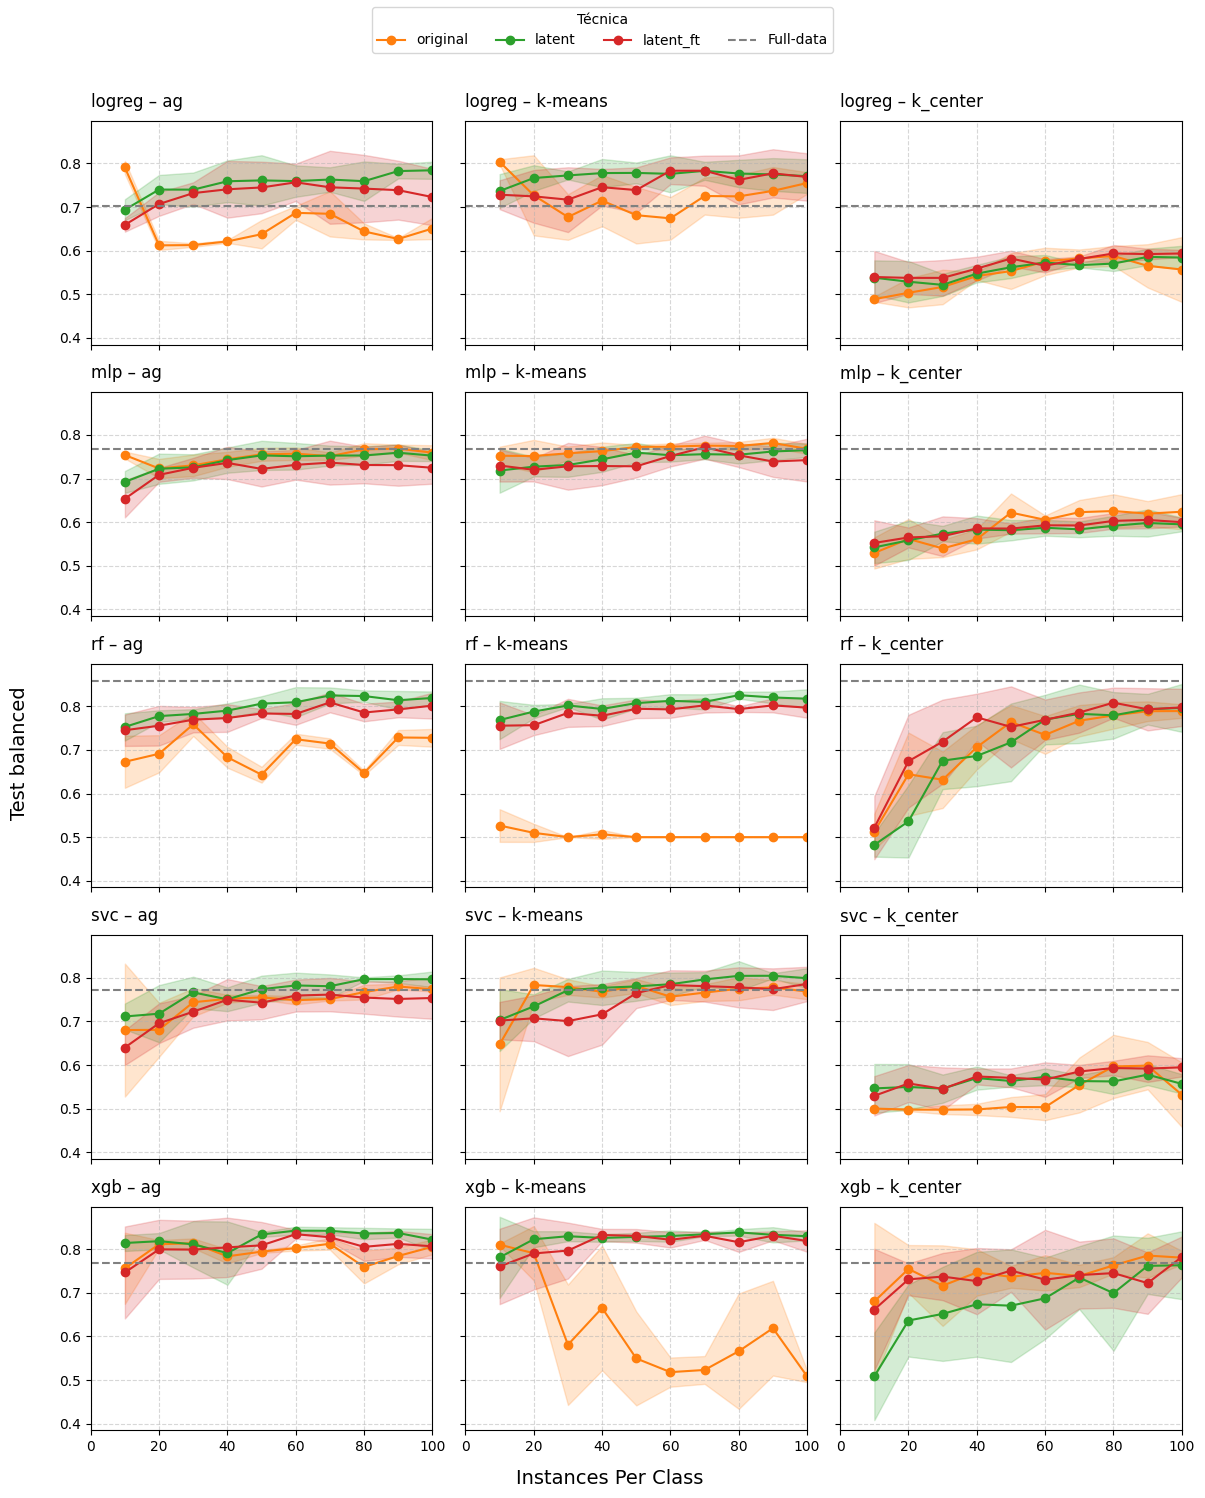

In [56]:
plot_metric_grid(
    df_random=df_metrics_random,
    df_original=df_metrics_original,
    df_latent=df_metrics_lat,
    df_latent_ft=df_metrics_lat_ft,
    space='original',      # o 'latent', según quieras filtrar
    metric='test_balanced'
)

## Experimento F


In [60]:
# Experimentos en los que se visualiza la métrica de balaned pero donde estos modelos entrenados tienen el problema
# De que fueron entrenados con codificadores erroneos a la hora de codificar la información reconstruida

df_metrics_original = pd.read_csv('Experiments_A/checkpoint_shoppers_Doriginal_Roriginal_A/metrics.csv')
df_metrics_original['method'] = df_metrics_original['method'].replace(
    'k_center', 'k-center'
)
df_metrics_lat = pd.read_csv('checkpoint_shoppers_Dlatent_F/metrics.csv')
df_metrics_lat_ft = pd.read_csv('checkpoint_shoppers_Dlatent_ft_F/metrics.csv')
df_metrics_random = df_metrics_original[df_metrics_original.method == 'random']

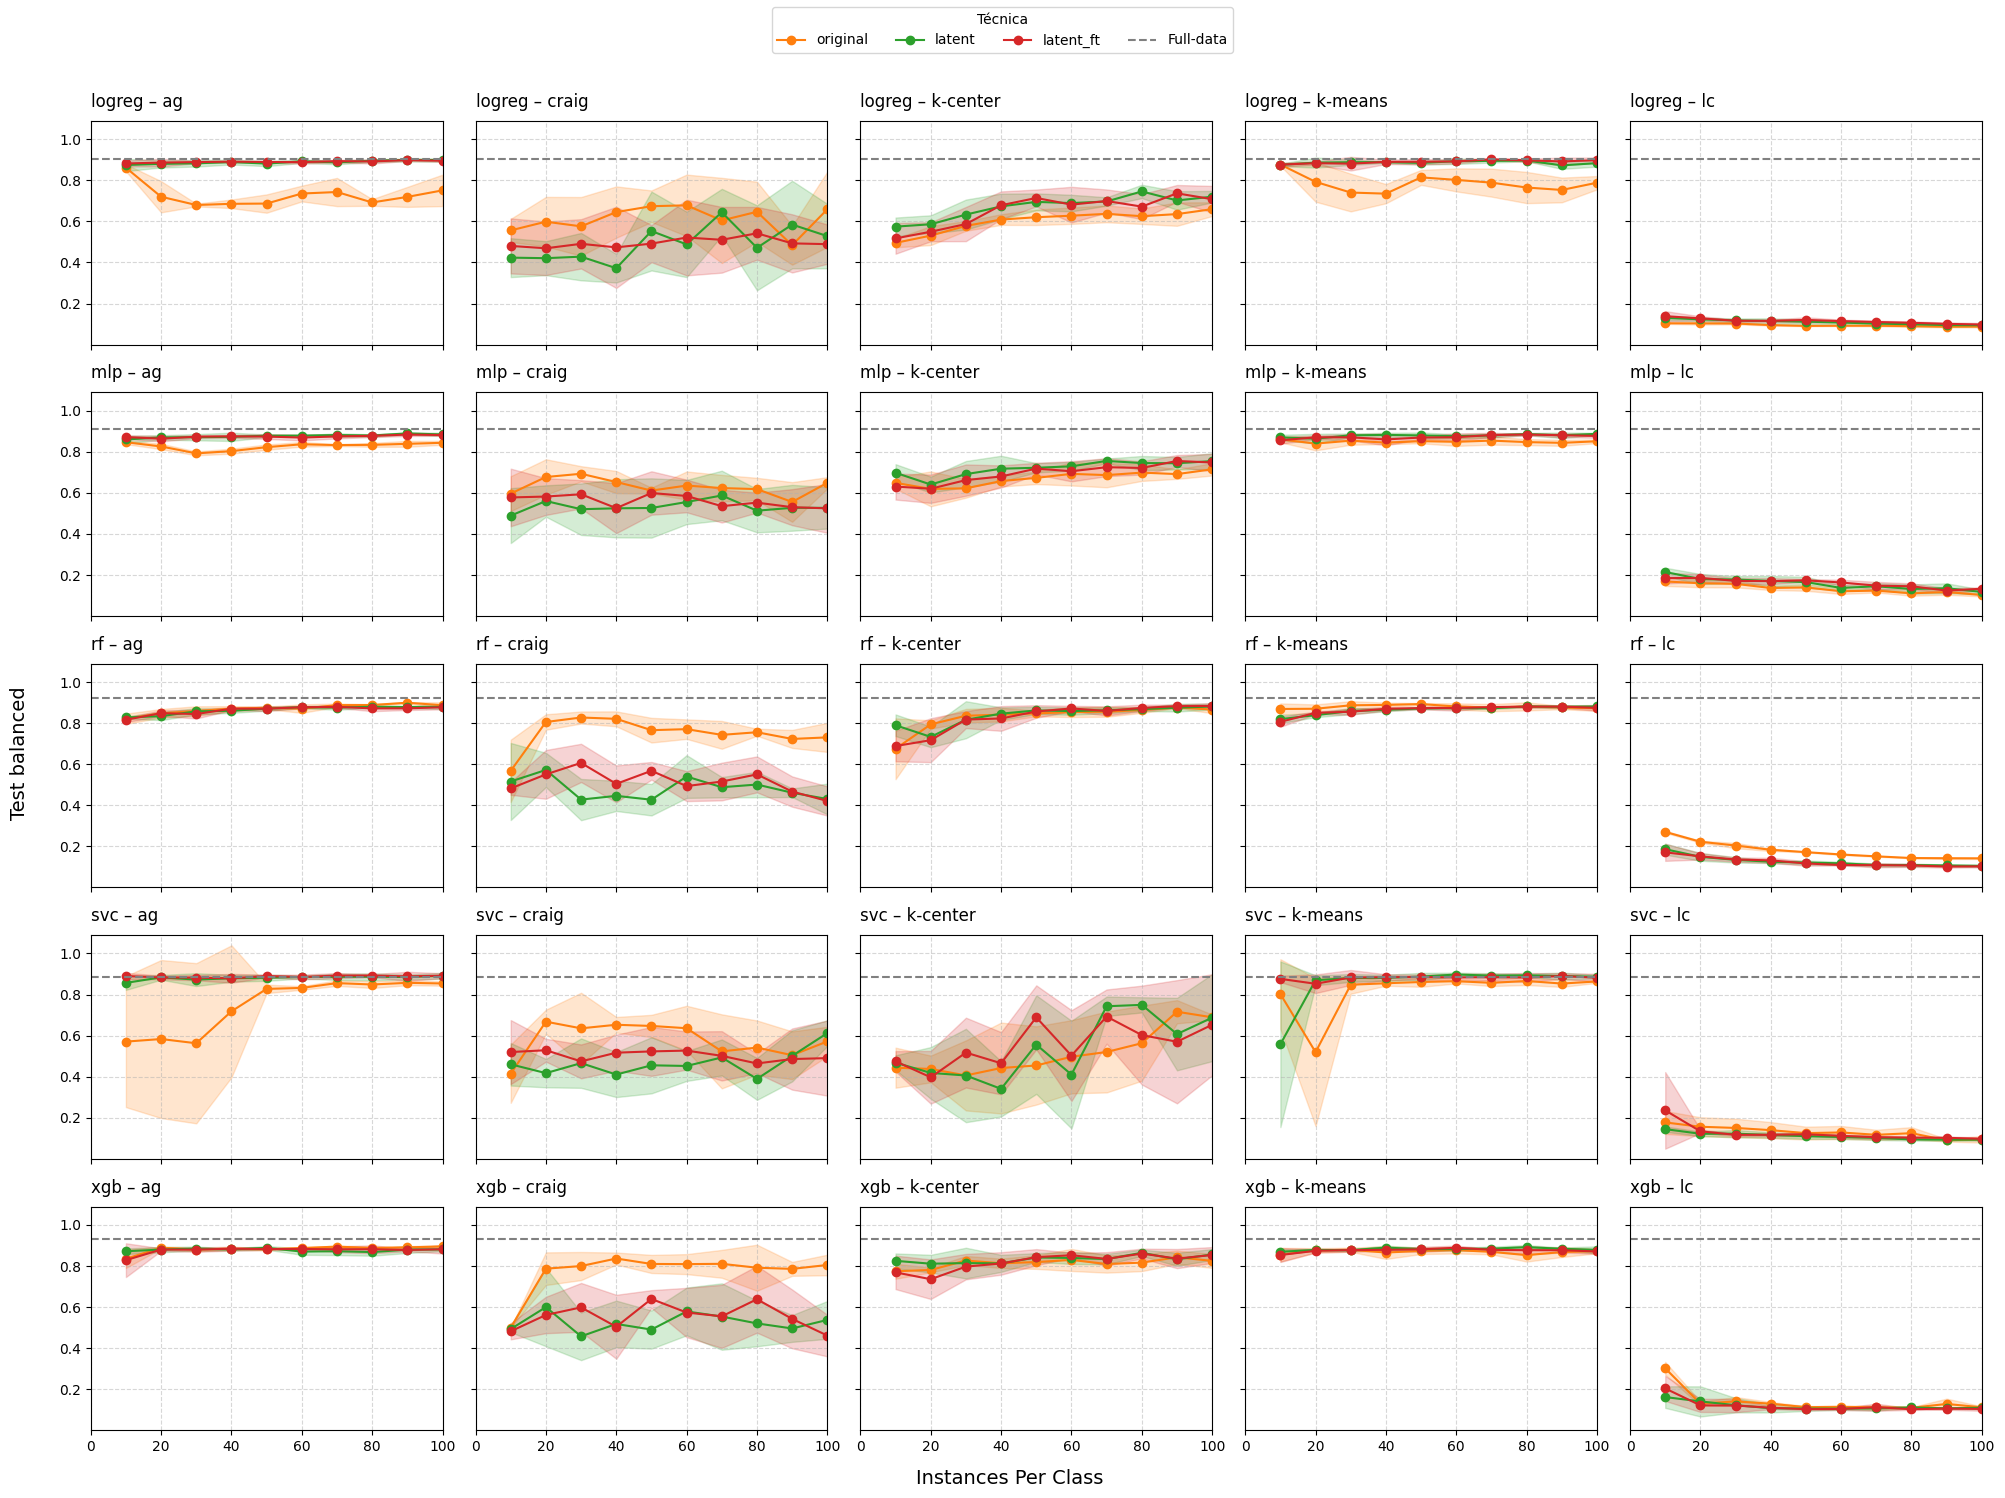

In [61]:
plot_metric_grid(
    df_random=df_metrics_random,
    df_original=df_metrics_original,
    df_latent=df_metrics_lat,
    df_latent_ft=df_metrics_lat_ft,
    space='original',      # o 'latent', según quieras filtrar
    metric='test_roc_auc'
)

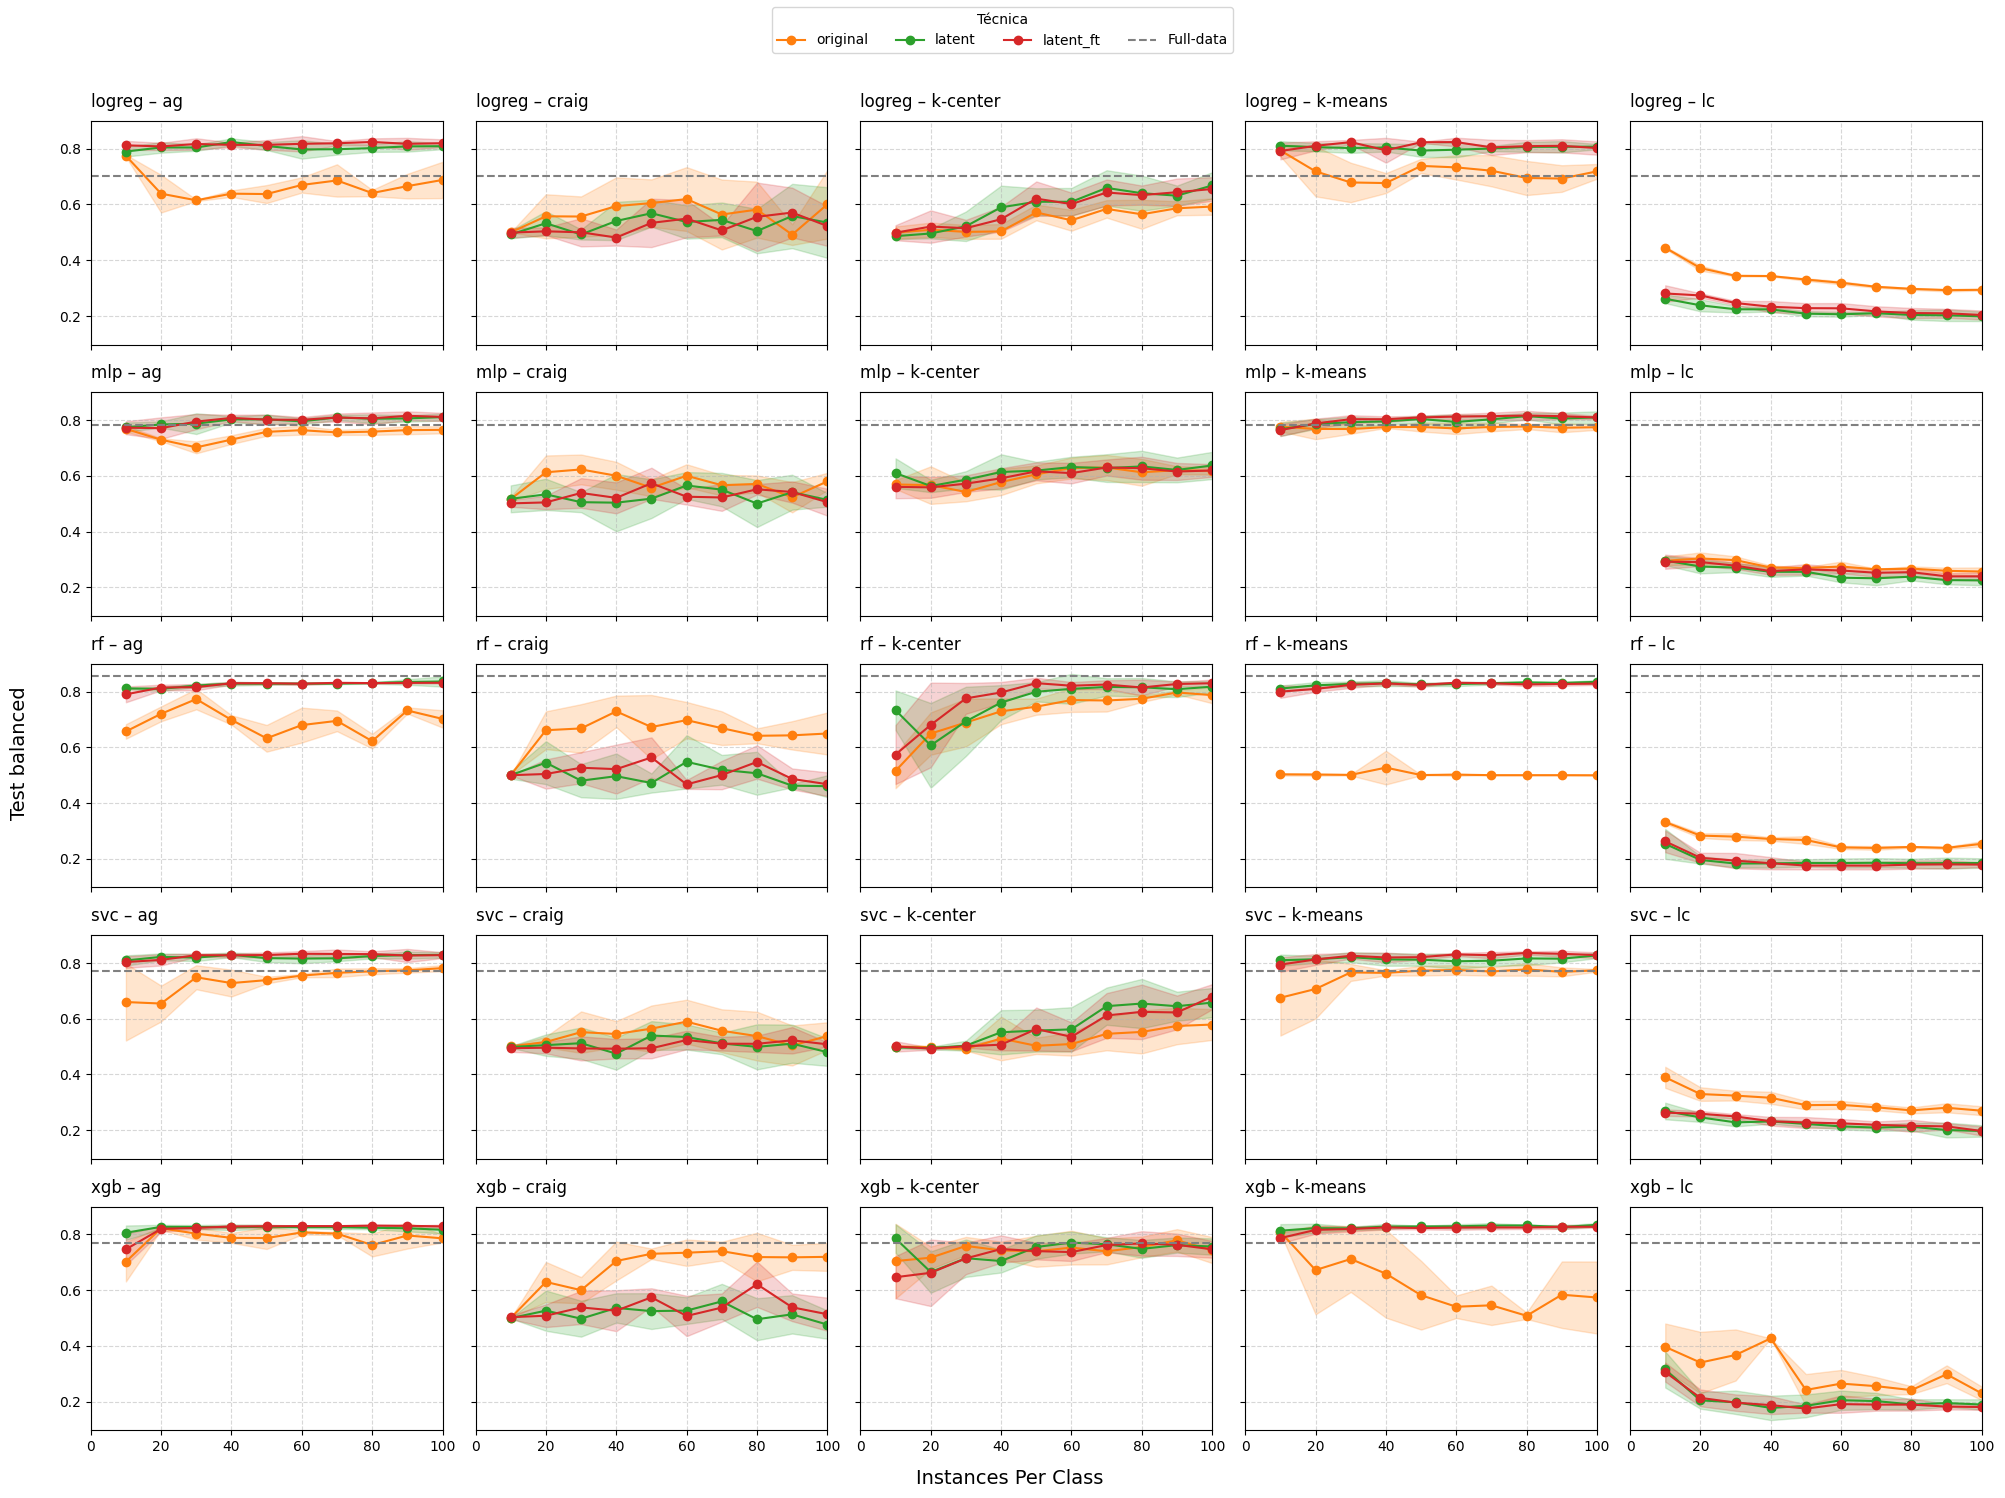

In [54]:
plot_metric_grid(
    df_random=df_metrics_random,
    df_original=df_metrics_original,
    df_latent=df_metrics_lat,
    df_latent_ft=df_metrics_lat_ft,
    space='latent',      # o 'latent', según quieras filtrar
    metric='test_balanced'
)

## Experimento G

In [56]:
df_metrics_original = pd.read_csv('checkpoint_adult_Doriginal_G/metrics.csv')
df_metrics_original['method'] = df_metrics_original['method'].replace(
    'k_center', 'k-center'
)
df_metrics_lat = pd.read_csv('checkpoint_adult_Dlatent_G/metrics.csv')
df_metrics_lat_ft = pd.read_csv('checkpoint_adult_Dlatent_ft_G/metrics.csv')
df_metrics_random = df_metrics_original[df_metrics_original.method == 'random']

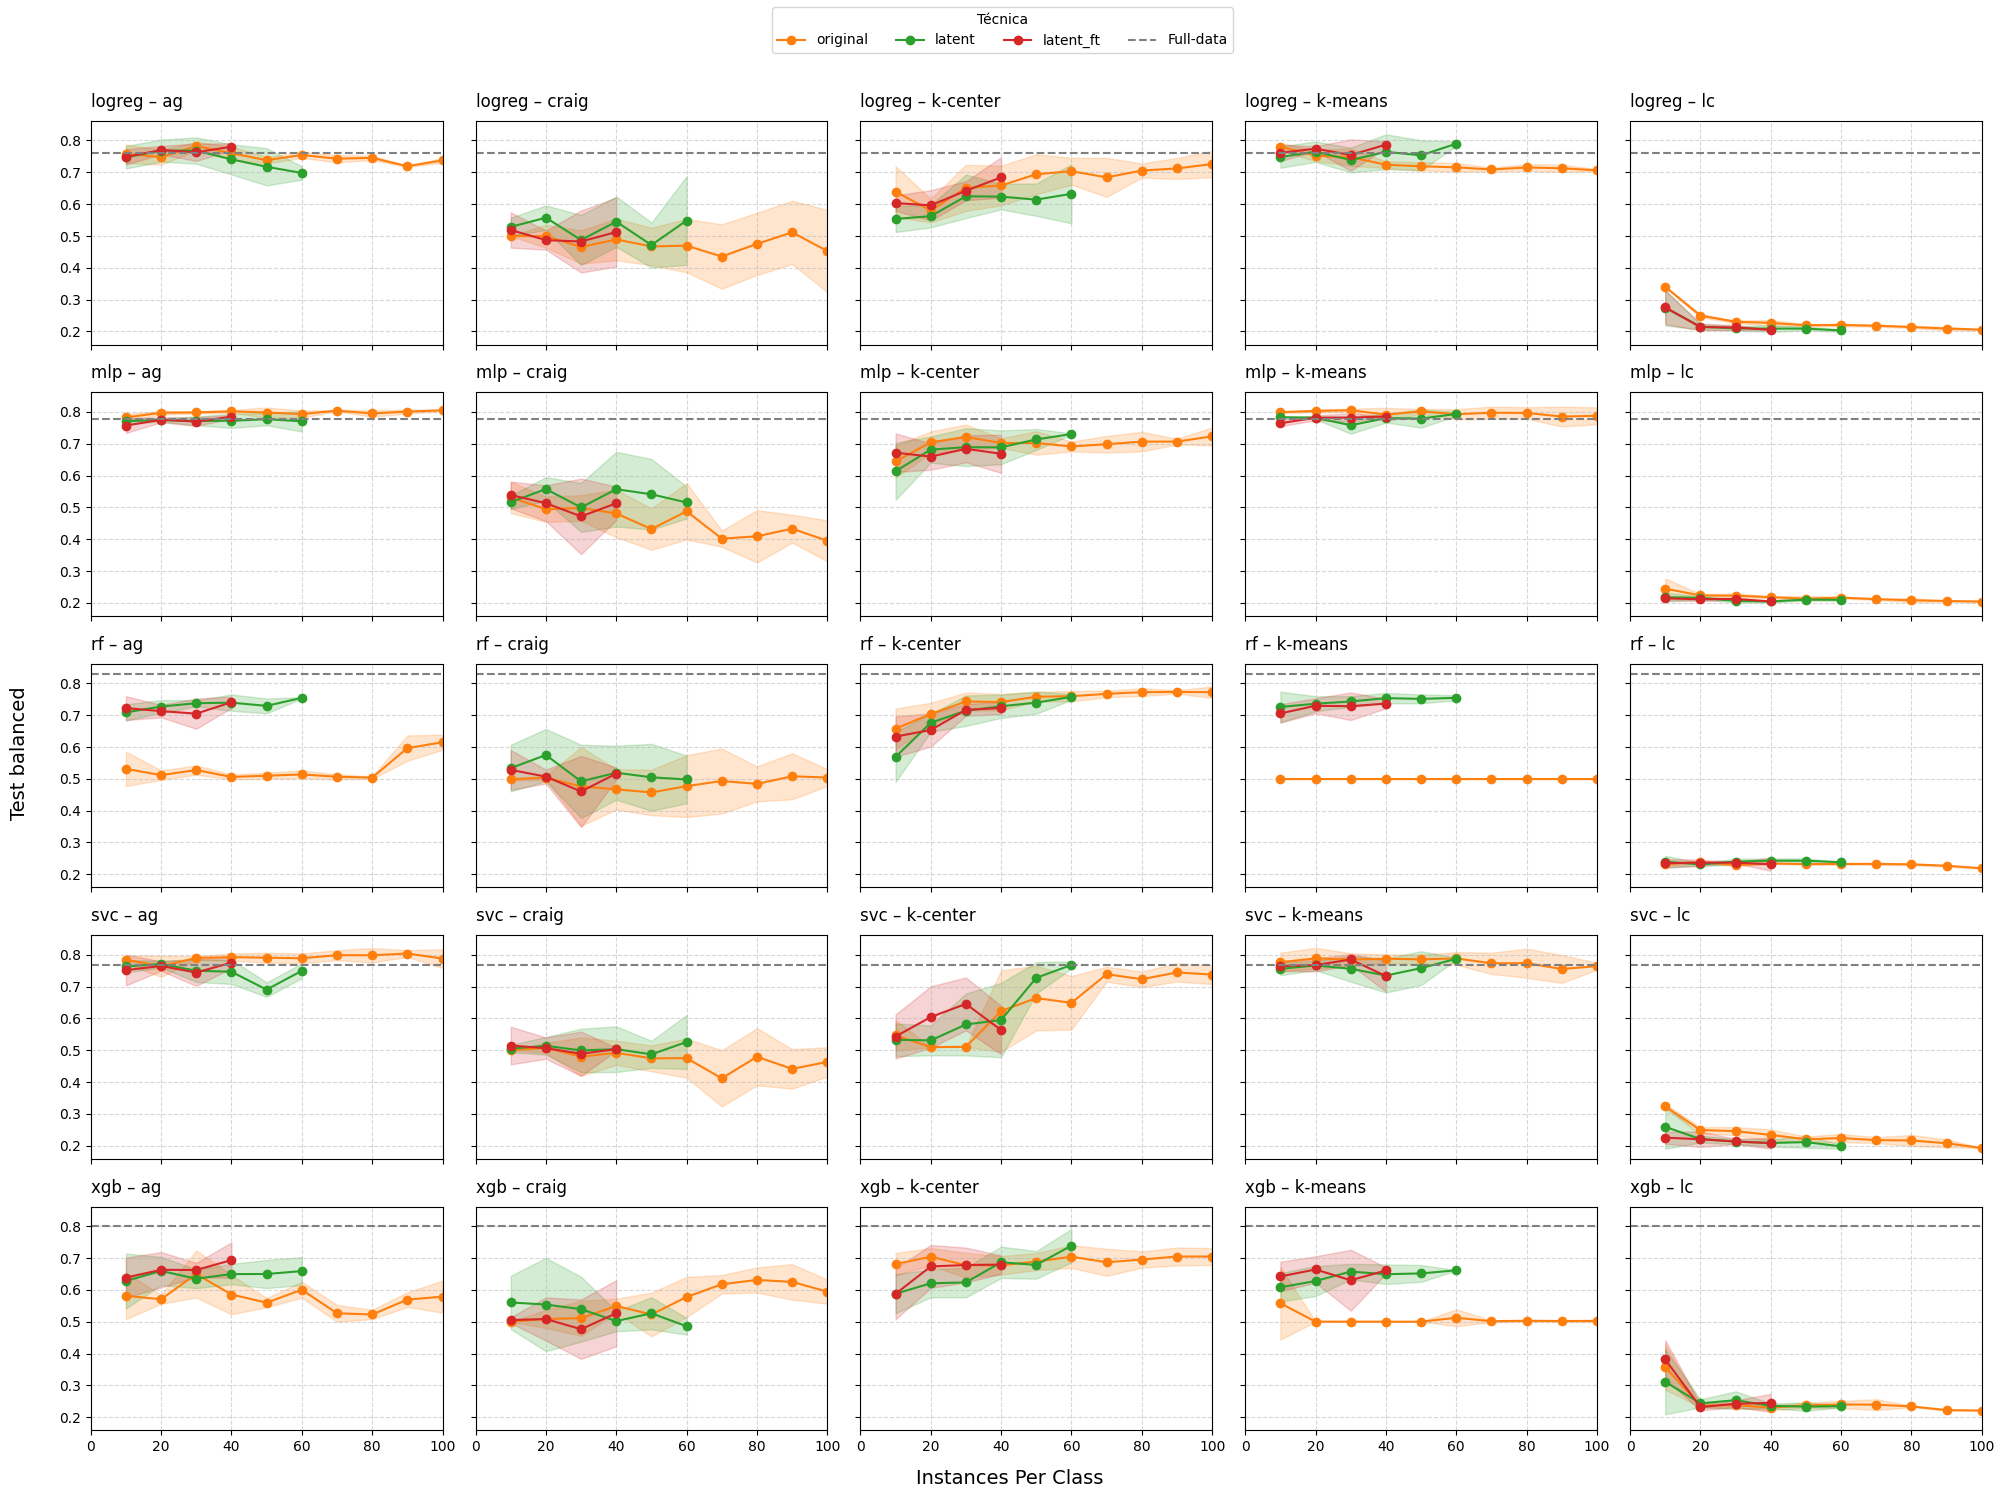

In [57]:
plot_metric_grid(
    df_random=df_metrics_random,
    df_original=df_metrics_original,
    df_latent=df_metrics_lat,
    df_latent_ft=df_metrics_lat_ft,
    space='original',      # o 'latent', según quieras filtrar
    metric='test_balanced'
)

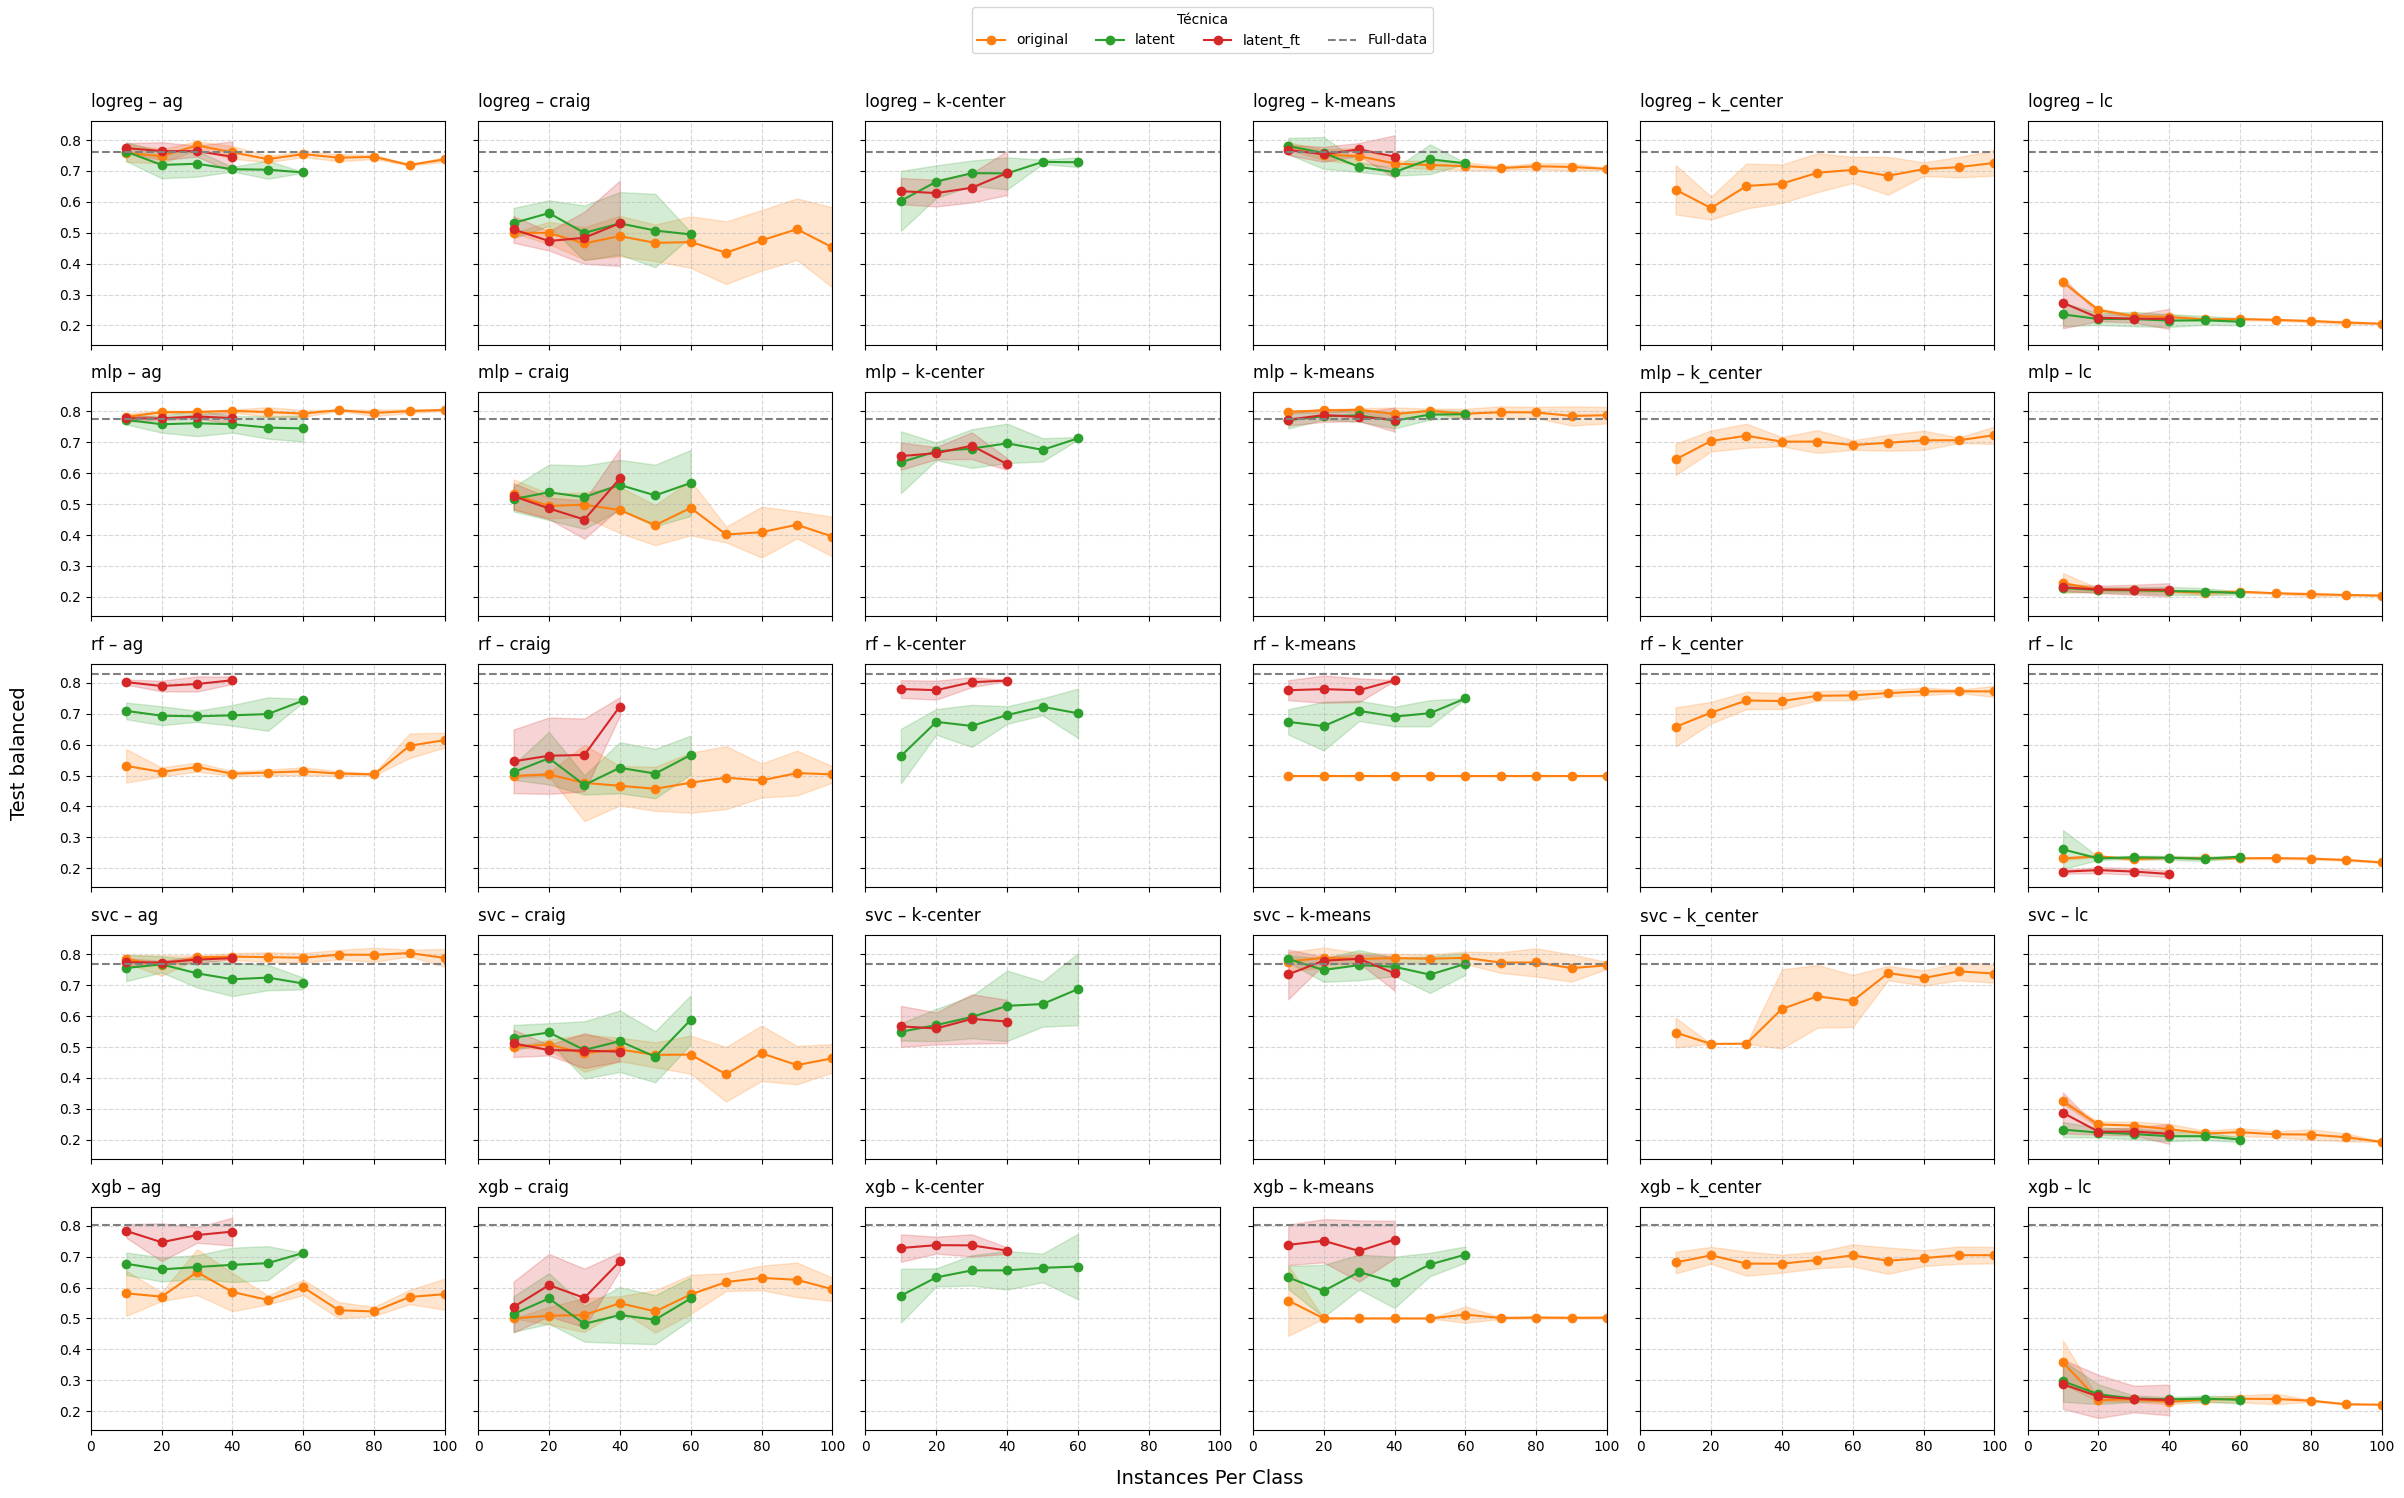

In [47]:
plot_metric_grid(
    df_random=df_metrics_random,
    df_original=df_metrics_original,
    df_latent=df_metrics_lat,
    df_latent_ft=df_metrics_lat_ft,
    space='latent',      # o 'latent', según quieras filtrar
    metric='test_balanced'
)

## Experimento H

In [62]:
# Experimentos en los que se visualiza la métrica de balaned pero donde estos modelos entrenados tienen el problema
# De que fueron entrenados con codificadores erroneos a la hora de codificar la información reconstruida

df_metrics_original = pd.read_csv('checkpoint_default_Doriginal_H/metrics.csv')
df_metrics_original['method'] = df_metrics_original['method'].replace(
    'k_center', 'k-center'
)
df_metrics_lat = pd.read_csv('checkpoint_default_Dlatent_G/metrics.csv')
df_metrics_lat_ft = pd.read_csv('checkpoint_default_Dlatent_ft_H/metrics.csv')
df_metrics_random = df_metrics_original[df_metrics_original.method == 'random']

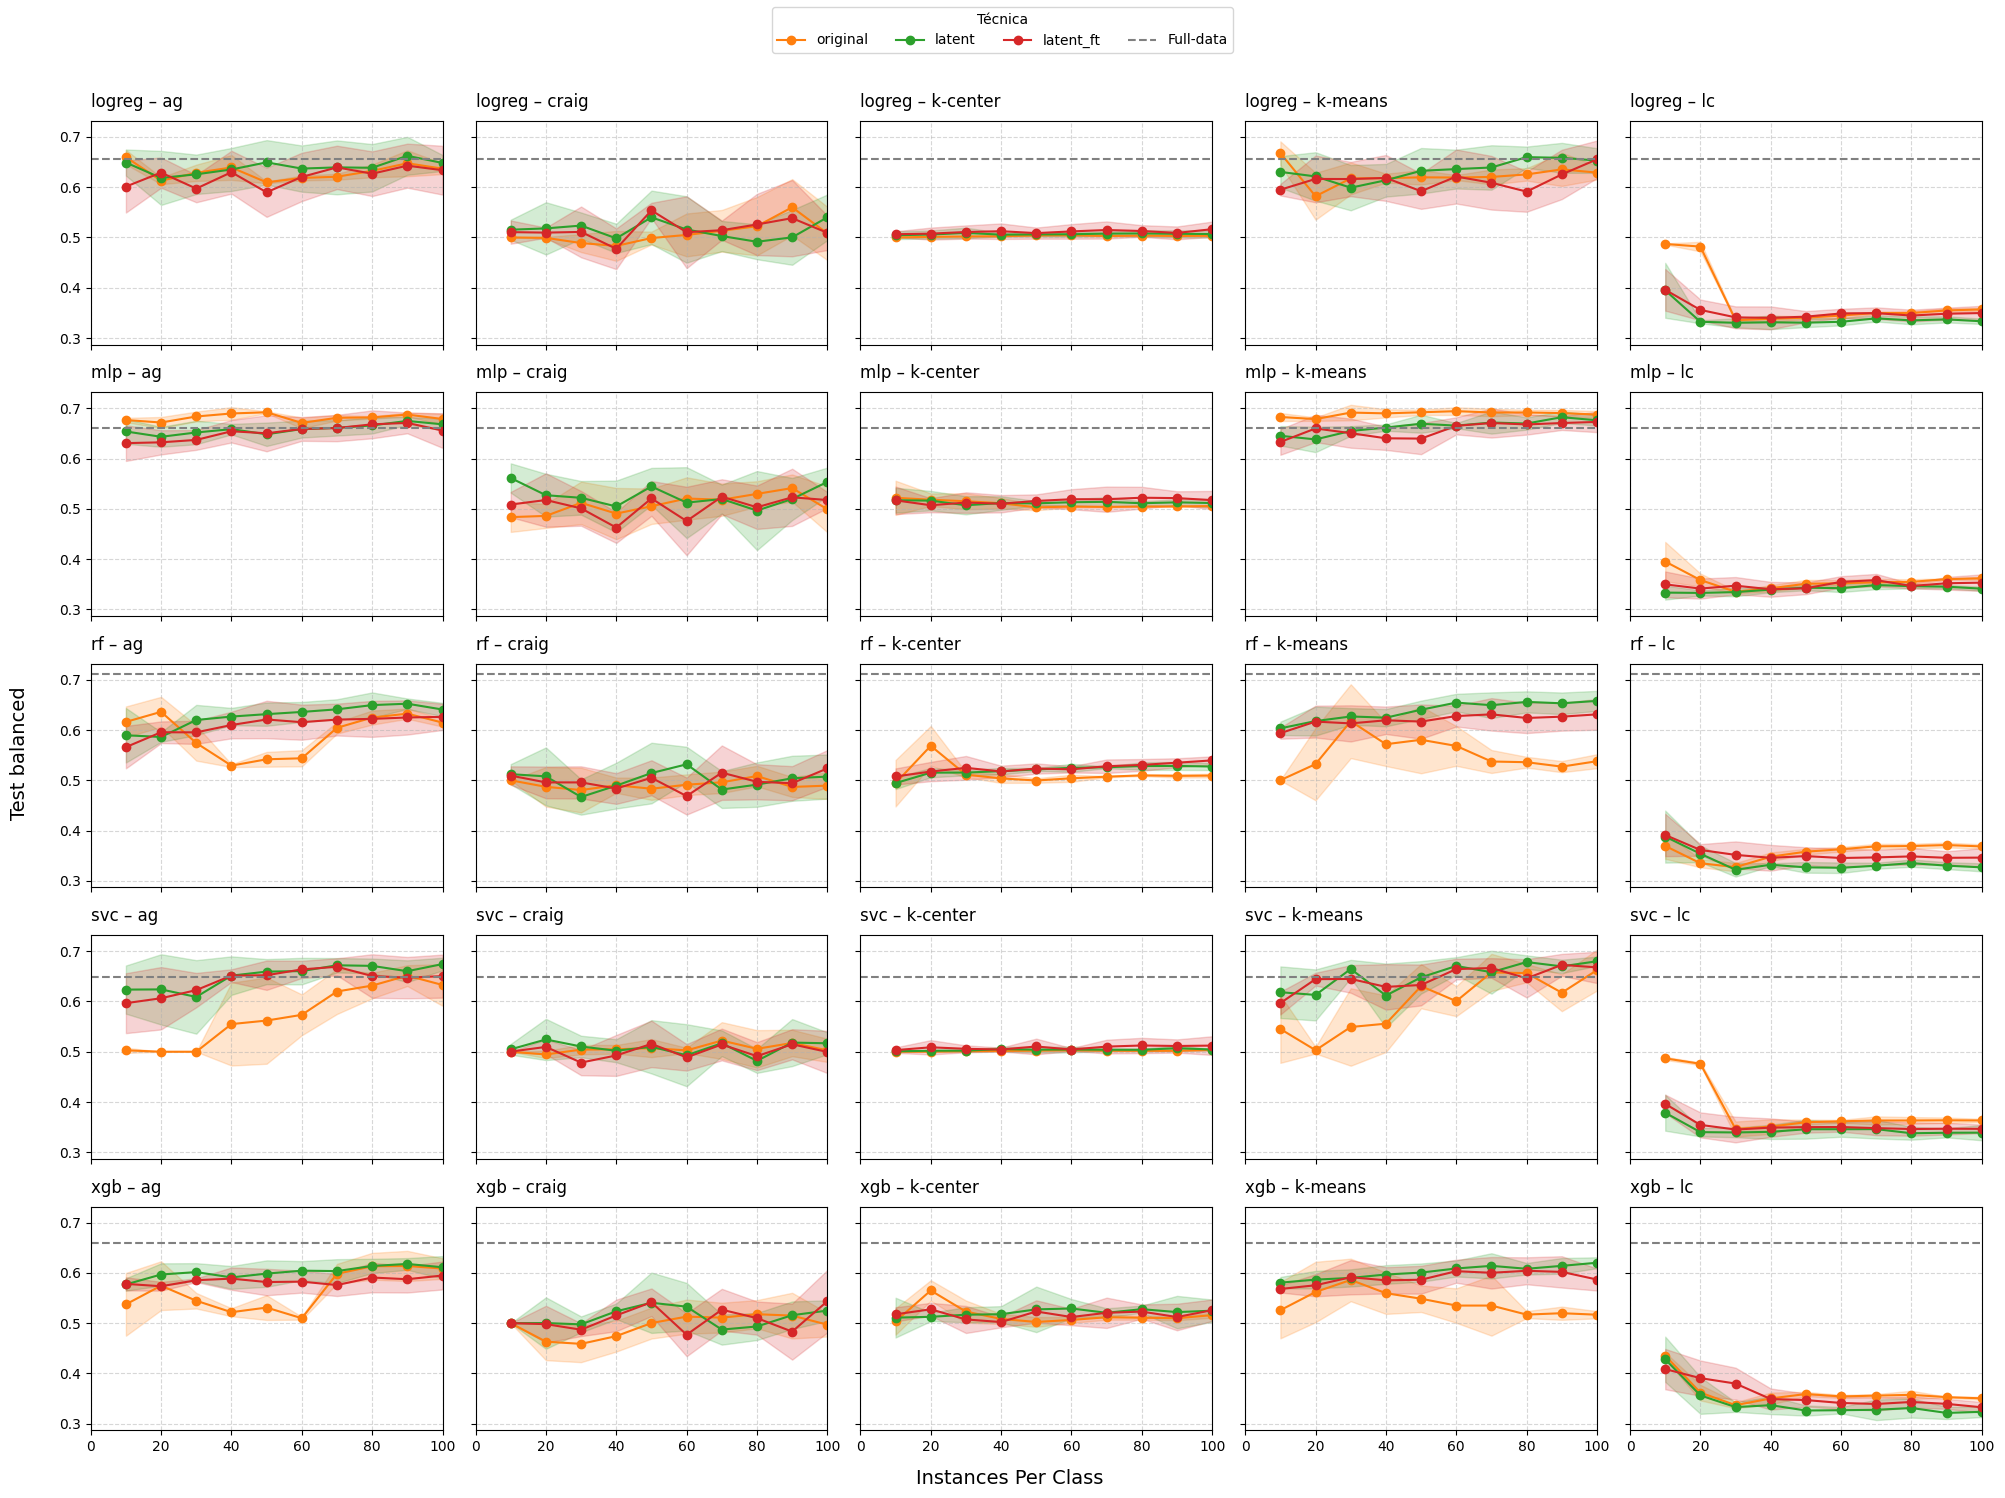

In [63]:
plot_metric_grid(
    df_random=df_metrics_random,
    df_original=df_metrics_original,
    df_latent=df_metrics_lat,
    df_latent_ft=df_metrics_lat_ft,
    space='original',      # o 'latent', según quieras filtrar
    metric='test_balanced'
)

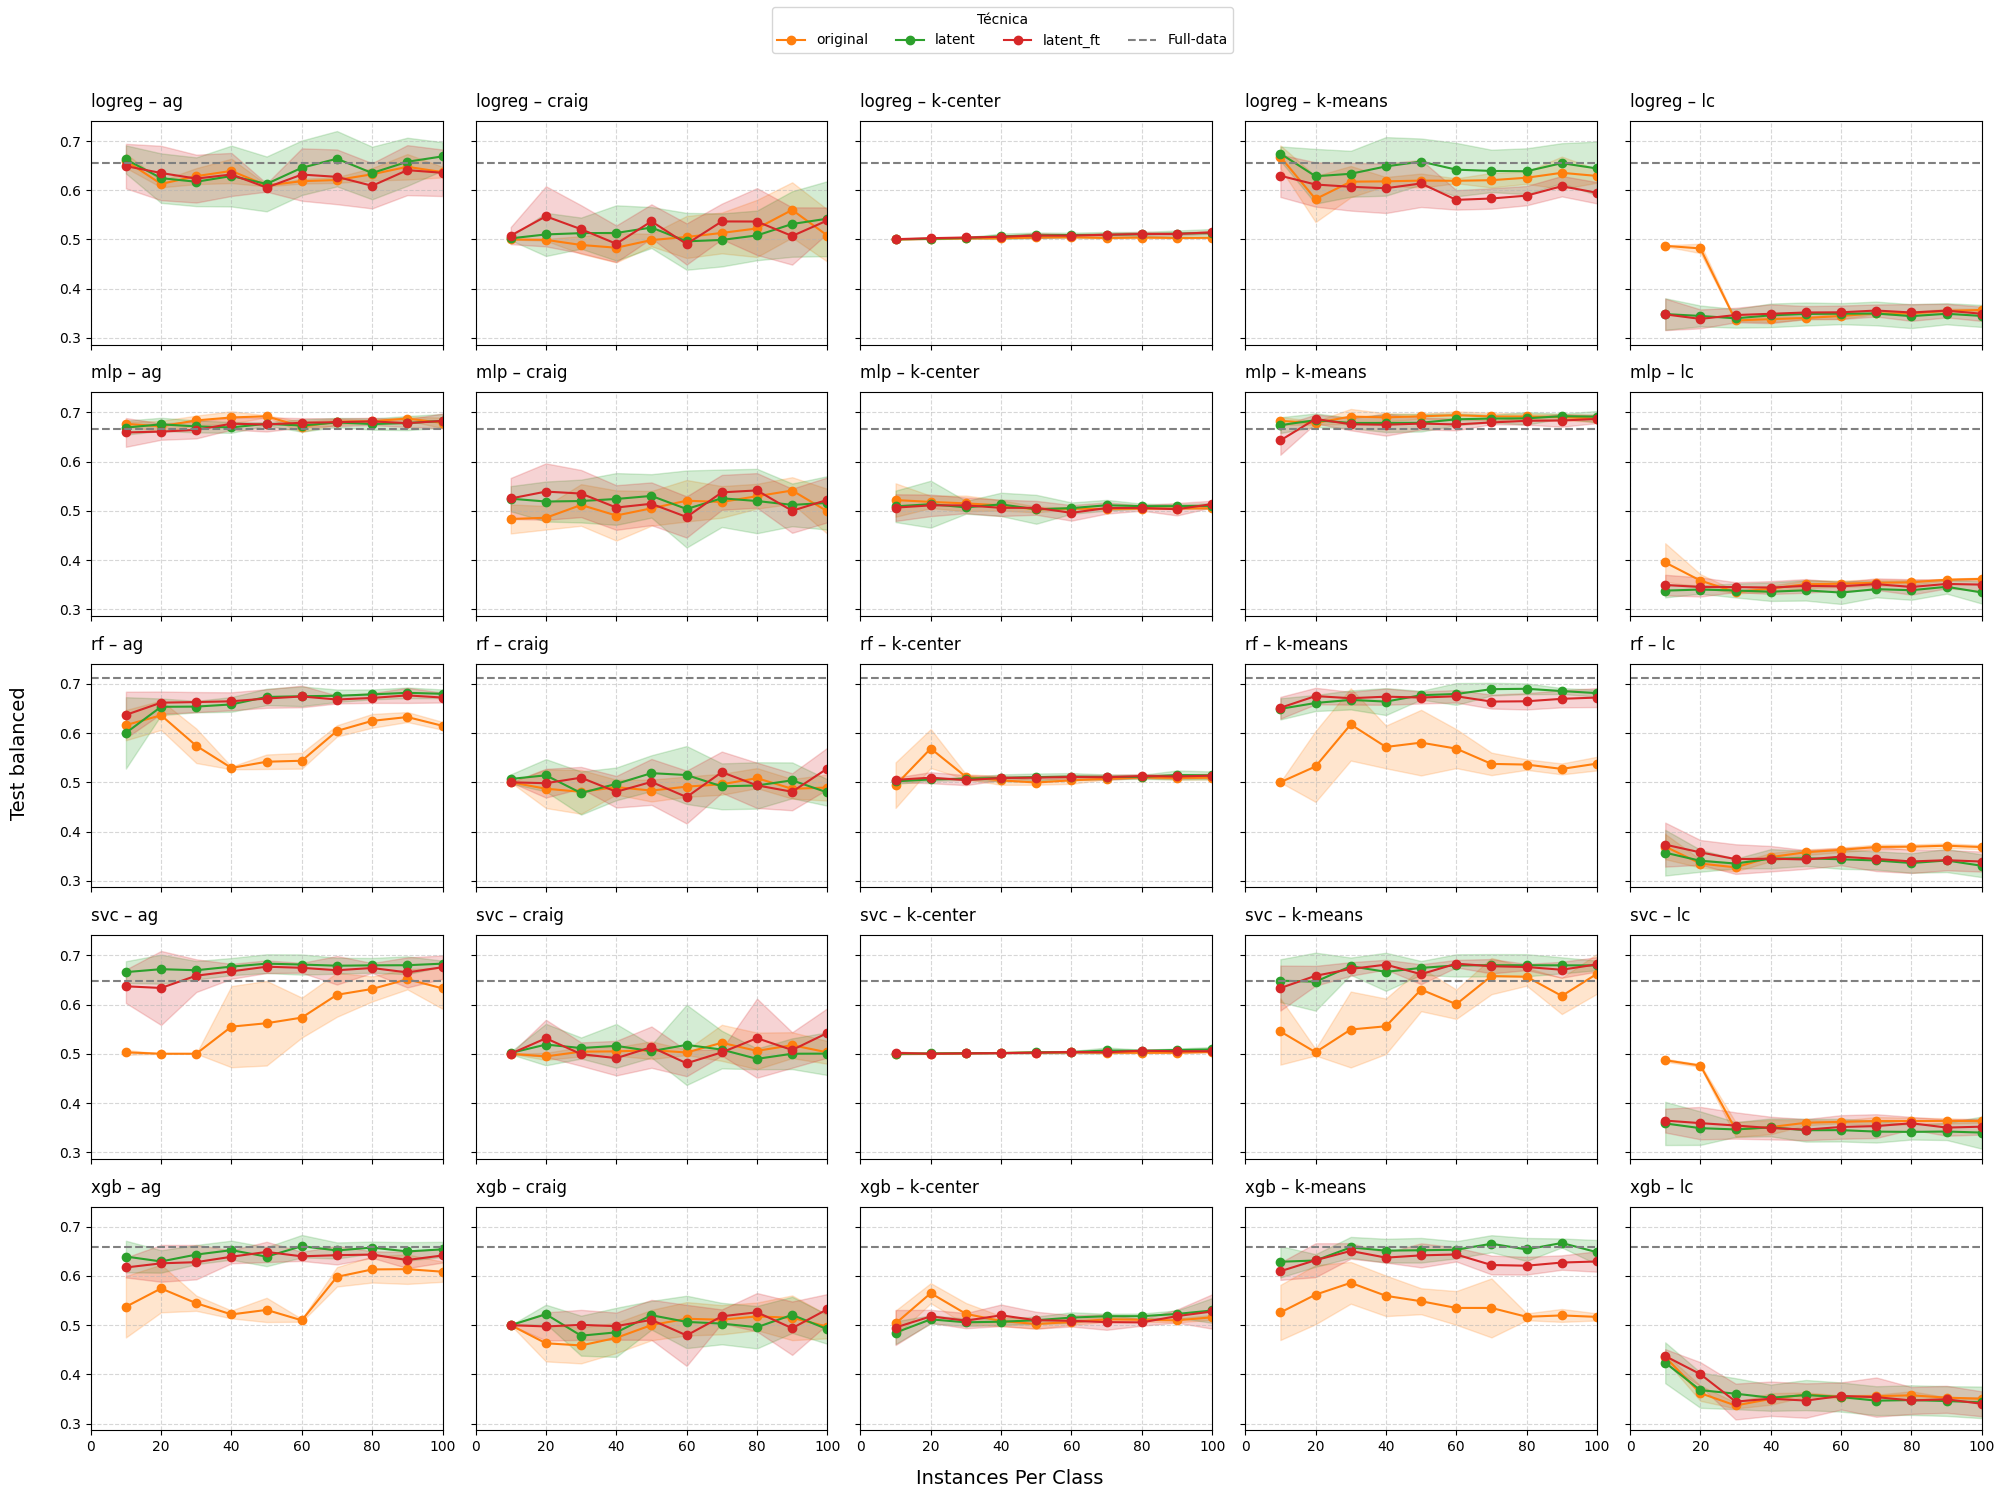

In [64]:
plot_metric_grid(
    df_random=df_metrics_random,
    df_original=df_metrics_original,
    df_latent=df_metrics_lat,
    df_latent_ft=df_metrics_lat_ft,
    space='latent',      # o 'latent', según quieras filtrar
    metric='test_balanced'
)

# Analisis de datos aleatorios con 20 seeds para ver varianza

In [7]:
df_metrics_random = pd.read_csv('pruebas_con_random/metrics_random.csv')


In [8]:
metric_col = 'test_balanced'
metric_col = 'test_roc_auc'
method = 'k-means'
model = 'xgb'
space = 'original'
mean_metric_col = f'mean_{metric_col}'
df_metrics_random.loc[(df_metrics_random.model ==model)].groupby(['IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col+'rand'})

,IPC,mean_test_roc_aucrand
0,10,0.8161


In [9]:
df_metrics_random = pd.read_csv('pruebas_con_random/metrics_random_30.csv')

In [10]:
metric_col = 'test_balanced'
metric_col = 'test_roc_auc'
method = 'k-means'
model = 'xgb'
space = 'original'
mean_metric_col = f'mean_{metric_col}'
df_metrics_random.loc[(df_metrics_random.model ==model)].groupby(['IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col+'rand'})

,IPC,mean_test_roc_aucrand
0,30,0.8805


# Analizando distribucion de los datos originales

# Analisis de shoppers

In [75]:
df_metrics_original = pd.read_csv('Experiments_B/checkpoint_shoppers_Doriginal_Roriginal_B/metrics.csv')
#df_metrics_original = pd.read_csv('Experiments_A/checkpoint_shoppers_Doriginal_Roriginal_A/metrics.csv')
df_metrics_lat = pd.read_csv('Experiments_B/checkpoint_shoppers_Dlatent_Roriginal_B/metrics.csv')
df_metrics_lat_ft = pd.read_csv('Experiments_B/checkpoint_shoppers_Dlatent_Roriginal_ft_B/metrics.csv')
df_metrics_lat_a = pd.read_csv('Experiments_A/checkpoint_shoppers_Dlatent_Roriginal_A/metrics.csv')

nuevo = pd.read_csv('pruebas_con_random/metrics_otro_latent.csv')
nuevo_2 = pd.read_csv('pruebas_con_random/metrics_otro_one-hot.csv')
nuevo_3 = pd.read_csv('pruebas_con_random/metrics_para_vae.csv') 
nuevo_4 = pd.read_csv('pruebas_con_random/metrics_para_vae_withoutadamw.csv') 

In [48]:
df_metrics_lat.columns

Index(['model', 'method', 'cv_balanced', 'cv_macro_f1', 'cv_weighted_f1',
       'cv_accuracy', 'cv_balanced_std', 'cv_macro_f1_std',
       'cv_weighted_f1_std', 'cv_accuracy_std', 'optuna_time', 'train_time',
       'test_balanced', 'test_macro_f1', 'test_weighted_f1', 'test_accuracy',
       'test_roc_auc', 'inf_time_per_sample', 'space', 'IPC', 'seed',
       'vae_pretrain_time', 'vae_fine_tunning_time', 'encoder_inference_time',
       'decoder_inference_time'],
      dtype='object')

In [49]:
df_metrics_lat.space.unique()

array(['original', 'latent'], dtype=object)

In [34]:
df_metrics_original[['test_balanced','test_roc_auc','model']].loc[df_metrics_original.method=='Full-data'].head(), df_metrics_lat[['test_balanced','test_roc_auc']].loc[df_metrics_lat.method=='Full-data'].head(), df_metrics_lat_ft[['test_balanced','test_roc_auc']].loc[df_metrics_lat_ft.method=='Full-data'].head()

(   test_balanced  test_roc_auc   model
 0          0.769         0.930     xgb
 1          0.859         0.919      rf
 2          0.771         0.885     svc
 3          0.702         0.902  logreg
 4          0.768         0.915     mlp,
    test_balanced  test_roc_auc
 0          0.769         0.930
 1          0.857         0.922
 2          0.771         0.884
 3          0.702         0.902
 4          0.758         0.912,
    test_balanced  test_roc_auc
 0          0.769         0.930
 1          0.860         0.919
 2          0.771         0.885
 3          0.702         0.902
 4          0.777         0.917)

In [35]:
r1 = df_metrics_original[['test_balanced', 'test_macro_f1', 'test_weighted_f1', 'test_accuracy','test_roc_auc']].loc[(df_metrics_original.method=='random')
                        & (df_metrics_original.model=='xgb') & (df_metrics_original.IPC==10)]
r1

,test_balanced,test_macro_f1,test_weighted_f1,test_accuracy,test_roc_auc
5,0.755,0.679,0.802,0.778,0.824
25,0.835,0.792,0.883,0.876,0.873
45,0.799,0.800,0.895,0.895,0.800
65,0.762,0.752,0.868,0.865,0.826
85,0.761,0.749,0.866,0.863,0.876


In [36]:
r2 = df_metrics_original[['test_accuracy','test_roc_auc']].loc[(df_metrics_original.method=='random')
                        & (df_metrics_original.model=='xgb') & (df_metrics_original.IPC==10)]

In [37]:
total = r1['test_roc_auc'].to_list()+r2['test_roc_auc'].to_list()
np.mean(total)

np.float64(0.8398)

In [70]:
# Graficando roc_auc

metric_col = 'test_balanced'
#metric_col = 'test_macro_f1'
metric_col = 'test_roc_auc'
method = 'k-means'
model = 'xgb'
space = 'original'

#metric_col = 'test_roc_auc'
mean_metric_col = f'mean_{metric_col}'
df_fil_original = df_metrics_original.loc[(df_metrics_original.method==method) & (df_metrics_original.model ==model)].groupby(['IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col})
df_fil_lat = df_metrics_lat.loc[(df_metrics_lat.method==method) & (df_metrics_lat.model ==model) & (df_metrics_lat.space ==space)].groupby(['IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col+'lat'})
df_fil_lat_ft = df_metrics_lat_ft.loc[(df_metrics_lat_ft.method==method) & (df_metrics_lat_ft.model ==model)& (df_metrics_lat.space ==space)].groupby(['IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col+'lat_ft'})

df_fil_random_ft = df_metrics_lat_ft.loc[(df_metrics_lat_ft.method=='random') & (df_metrics_lat_ft.model ==model)].groupby(['IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col+'rand'})

df1 = df_fil_original.set_index('IPC')
df2 = df_fil_lat.set_index('IPC')
df3 = df_fil_lat_ft.set_index('IPC')
df4 = df_fil_random_ft.set_index('IPC')

# 2) Concatenar horizontalmente (axis=1)
df_concat = pd.concat([df1, df2, df3,df4], axis=1)

# 3) (Opcional) devolver 'IPC' como columna
df_concat = df_concat.reset_index()
df_concat

,IPC,mean_test_roc_auc,mean_test_roc_auclat,mean_test_roc_auclat_ft,mean_test_roc_aucrand
0,10.0,0.8538,0.8326,0.8332,0.8398
1,20.0,0.8564,0.8738,0.8884,0.8584
2,30.0,0.8742,0.8750,0.8814,0.8768
3,40.0,0.8406,0.8806,0.8790,0.8742
4,50.0,0.8734,0.8882,0.8754,0.8944
5,60.0,0.8580,0.8832,0.8788,0.8968
6,70.0,0.8664,0.8796,0.8808,0.8954
7,80.0,0.8740,0.8822,0.8688,0.8976
8,90.0,0.8808,0.8908,0.8778,0.8896
9,100.0,0.8686,0.8864,0.8638,0.8890


In [74]:
metric_col = 'test_roc_auc'
#metric_col = 'test_balanced'
method = 'k-means'
model = 'xgb'
space = 'original'

nuevo_a = df_metrics_lat_a.loc[(df_metrics_lat_a.method==method) & (df_metrics_lat_a.model ==model)].groupby(['IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col+'lat_ft_nuevo'})
nuevo_a

,IPC,mean_test_roc_auclat_ft_nuevo
0,10.0,0.8588
1,20.0,0.8680
2,30.0,0.8698
3,40.0,0.8686
4,50.0,0.8746
5,60.0,0.8912
6,70.0,0.8908
7,80.0,0.8778
8,90.0,0.8718
9,100.0,0.8870


In [ ]:
# Este experimento es utilizando el codificador de ordinal para MLE

metric_col = 'test_roc_auc'
metric_col = 'test_balanced'
method = 'k-means'
model = 'rf'
space = 'original'

nuevo_a = nuevo.loc[(nuevo.method==method) & (nuevo.model ==model)& (nuevo.space ==space)].groupby(['IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col+'lat_ft_nuevo'})
nuevo_a

,IPC,mean_test_balancedlat_ft_nuevo
0,10,0.7782
1,20,0.7994
2,30,0.8196
3,40,0.8280
4,50,0.8284
5,60,0.8258
6,70,0.8268
7,80,0.8312
8,90,0.8302
9,100,0.8348


In [77]:
# Este experimento es utilizando el decodificador de one-hot para MLE

metric_col = 'test_roc_auc'
#metric_col = 'test_balanced'
method = 'k-means'
model = 'xgb'
space = 'original'

nuevo_a = nuevo_2.loc[(nuevo_2.method==method) & (nuevo_2.model ==model)& (nuevo_2.space ==space)].groupby(['IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col+'lat_ft_nuevo'})
nuevo_a

,IPC,mean_test_roc_auclat_ft_nuevo
0,10,0.8724
1,20,0.8820
2,30,0.8828
3,40,0.8762
4,50,0.8892
5,60,0.8758
6,70,0.8870
7,80,0.8832
8,90,0.8922
9,100,0.8888


In [ ]:
# Este experimento corresponde a entrenar nuevamente con ONE-hot pero cambiando los parametros de lambda a 0.5 para el calculo de KL y utilizando un num layers de 2

metric_col = 'test_roc_auc'
#metric_col = 'test_balanced'
method = 'random'
model = 'xgb'
space = 'original'

nuevo_a = nuevo_3.loc[(nuevo_3.method==method) & (nuevo_3.model ==model)& (nuevo_3.space ==space)].groupby(['IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col+'lat_ft_nuevo'})
nuevo_a

,IPC,mean_test_roc_auclat_ft_nuevo
0,10,0.8398
1,20,0.8584
2,30,0.8768
3,40,0.8742
4,50,0.8944
5,60,0.8968
6,70,0.8930


In [76]:
# Este experimento corresponde a entrenar nuevamente con ONE-hot pero cambiando los parametros de lambda a 0.5 para el calculo de KL y utilizando un num layers de 2

metric_col = 'test_roc_auc'
#metric_col = 'test_balanced'
method = 'random'
model = 'xgb'
space = 'original'

nuevo_a = nuevo_4.loc[(nuevo_4.method==method) & (nuevo_4.model ==model)& (nuevo_4.space ==space)].groupby(['IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col+'lat_ft_nuevo'})
nuevo_a

,IPC,mean_test_roc_auclat_ft_nuevo
0,10,0.8398
1,20,0.8390


In [ ]:
df_metrics_lat.loc[(df_metrics_lat.method==method) & (df_metrics_lat.model ==model)].space.unique()

array(['original'], dtype=object)

In [55]:
df_metrics_original = pd.read_csv('checkpoint_shoppers_Doriginal_Roriginal/metrics.csv')
df_metrics_lat = pd.read_csv('checkpoint_shoppers_Dlatent_Roriginal/metrics.csv')
df_metrics_lat_ft = pd.read_csv('checkpoint_shoppers_Dlatent_Roriginal_ft/metrics.csv')

# Graficando roc_auc

metric_col = 'test_balanced'
metric_col = 'test_roc_auc'
#metric_col = 'test_weighted_f1'
method = 'k-means'
model = 'xgb'

#metric_col = 'test_roc_auc'
mean_metric_col = f'mean_{metric_col}'
df_fil_original = df_metrics_original.loc[(df_metrics_original.method==method) & (df_metrics_original.model ==model)].groupby(['IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col})
df_fil_lat = df_metrics_lat.loc[(df_metrics_lat.method==method) & (df_metrics_lat.model ==model)].groupby(['IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col+'lat'})
df_fil_lat_ft = df_metrics_lat_ft.loc[(df_metrics_lat_ft.method==method) & (df_metrics_lat_ft.model ==model)].groupby(['IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col+'lat_ft'})
df_fil_random_ft = df_metrics_lat_ft.loc[(df_metrics_lat_ft.method=='random') & (df_metrics_lat_ft.model ==model)].groupby(['IPC'], as_index=False)[metric_col].mean().rename(columns={metric_col:mean_metric_col+'rand'})

df1 = df_fil_original.set_index('IPC')
df2 = df_fil_lat.set_index('IPC')
df3 = df_fil_lat_ft.set_index('IPC')
df4 = df_fil_random_ft.set_index('IPC')

# 2) Concatenar horizontalmente (axis=1)
df_concat = pd.concat([df1, df2, df3,df4], axis=1)

# 3) (Opcional) devolver 'IPC' como columna
df_concat = df_concat.reset_index()
df_concat

FileNotFoundError: [Errno 2] No such file or directory: 'checkpoint_shoppers_Doriginal_Roriginal/metrics.csv'

In [ ]:
df_metrics_lat.columns

Index(['model', 'method', 'cv_balanced', 'cv_macro_f1', 'cv_weighted_f1',
       'cv_accuracy', 'cv_balanced_std', 'cv_macro_f1_std',
       'cv_weighted_f1_std', 'cv_accuracy_std', 'optuna_time', 'train_time',
       'test_balanced', 'test_macro_f1', 'test_weighted_f1', 'test_accuracy',
       'test_roc_auc', 'inf_time_per_sample', 'IPC', 'seed',
       'vae_pretrain_time', 'vae_fine_tunning_time', 'encoder_inference_time',
       'decoder_inference_time'],
      dtype='object')

In [ ]:
df_metrics_lat.method.unique()

array(['Full-data', 'random', 'k-means', 'ag', 'k_center', 'craig', 'lc'],
      dtype=object)

In [ ]:
df_metrics_original[['model','test_balanced','test_roc_auc','IPC']][(df_metrics_original['IPC'].isin([90,np.nan])) & (df_metrics_original['model'] == 'xgb')]

,model,test_balanced,test_roc_auc,IPC
0,xgb,0.769,0.930,NaN
1205,xgb,0.835,0.900,90.0
1210,xgb,0.512,0.862,90.0
1215,xgb,0.825,0.897,90.0
1220,xgb,0.805,0.867,90.0
1225,xgb,0.769,0.807,90.0
1230,xgb,0.331,0.165,90.0
1235,xgb,0.831,0.893,90.0
1240,xgb,0.498,0.878,90.0
1245,xgb,0.718,0.882,90.0


Calculo de test roc auc

In [ ]:
metric = 'test_roc_auc'
metric = 'test_balanced'

df_random = df_metrics_lat[df_metrics_lat.method == 'random']
df_real = df_metrics_lat[df_metrics_lat.method == 'Full-data']

rr_original,_, df_join_AF_AR = compute_all_relative_regret(df_metrics_original, df_random, df_real, metric_col=metric)
rr_lat,_,_ = compute_all_relative_regret(df_metrics_lat,df_random, df_real, metric_col=metric)
rr_lat_ft,_,_ = compute_all_relative_regret(df_metrics_lat_ft,df_random, df_real, metric_col=metric)
rr_random = rr_lat.loc[rr_lat.method == 'random']

Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
Denominador menor que cero
D

In [ ]:
df_join_AF_AR

,AF,AR,AF_minus_AR
model,,,
xgb,0.769,0.7824,-0.0134
rf,0.857,0.7384,0.1186
svc,0.771,0.7038,0.0672
logreg,0.702,0.7582,-0.0562
mlp,0.758,0.7110,0.0470


In [ ]:
rr_random.shape, rr_original.shape

((65, 5), (390, 5))

In [ ]:
rr_random.head()

,method,model,IPC,A,regret
325,random,logreg,10.0,0.8278,1.000000
326,random,logreg,20.0,0.8386,0.854447
327,random,logreg,30.0,0.8592,0.576819
328,random,logreg,40.0,0.8604,0.560647
329,random,logreg,50.0,0.8650,0.498652


In [ ]:
rr_original.head()

,method,model,IPC,A,regret
0,ag,logreg,10.0,0.8610,0.552561
1,ag,logreg,20.0,0.7198,2.455526
2,ag,logreg,30.0,0.6796,2.997305
3,ag,logreg,40.0,0.6854,2.919137
4,ag,logreg,50.0,0.6866,2.902965


In [ ]:
rr_original.method.unique()

array(['ag', 'craig', 'k-means', 'k_center', 'lc', 'random'], dtype=object)

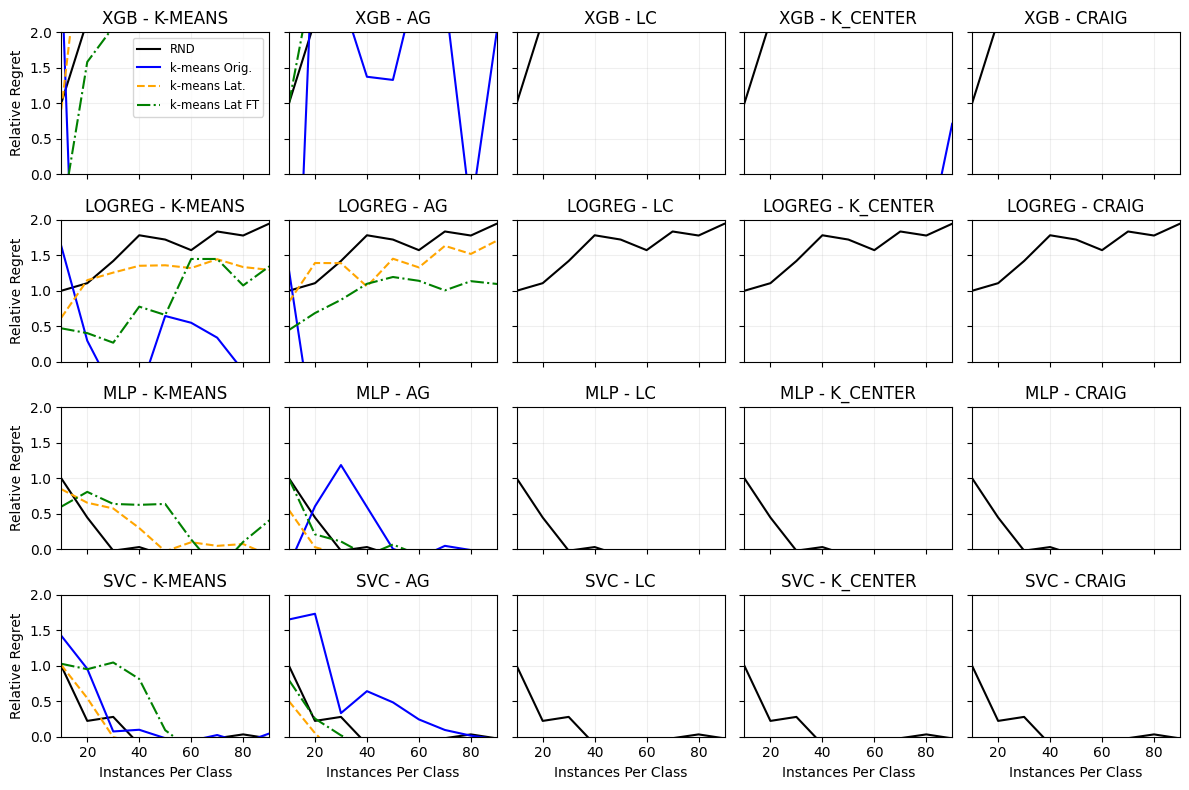

In [ ]:
models = ['xgb','logreg','mlp','svc']
methods = ['k-means','ag','lc','k_center','craig']
ipc_values = sorted(rr_original['IPC'].unique())[:9]

plot_regret_grid(
    rr_original=rr_original,
    rr_lat=rr_lat,
    rr_lat_ft=rr_lat_ft,
    rr_random = rr_random,
    models=models,
    methods=methods,
    ipc_values=ipc_values
)

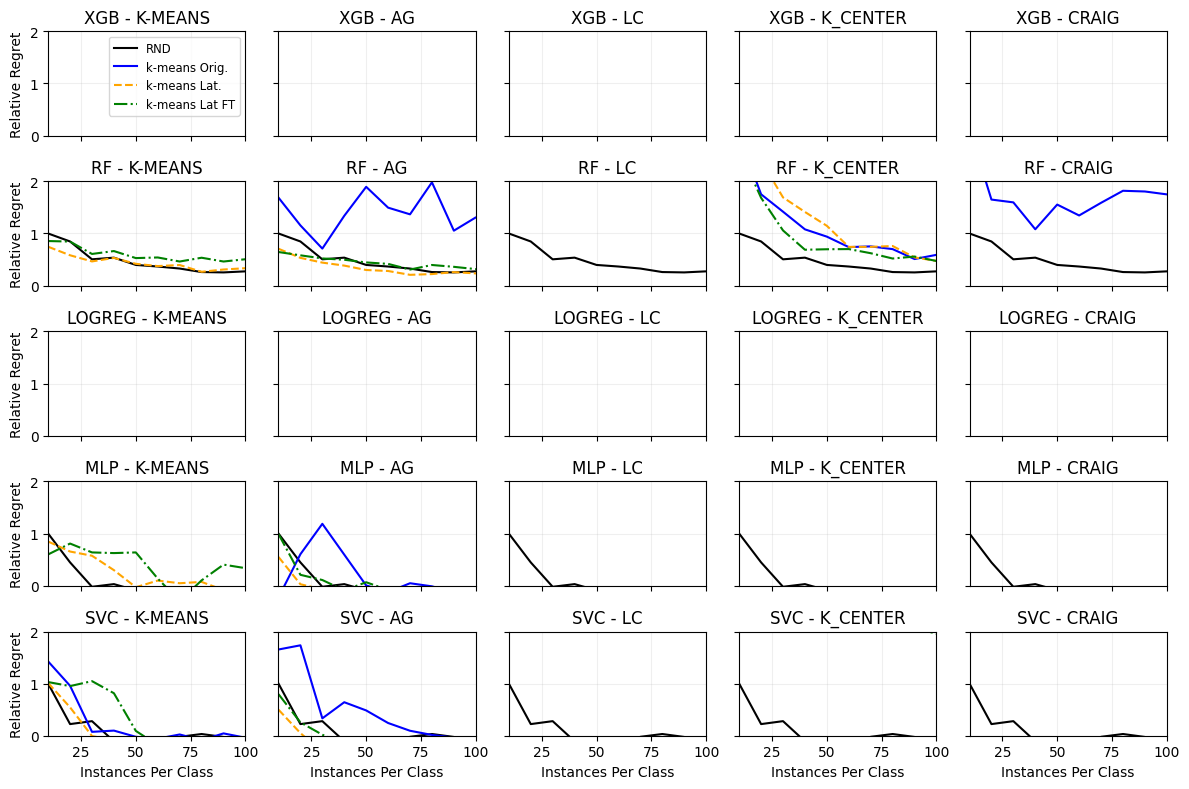

In [ ]:
models = ['xgb','rf','logreg','mlp','svc']
methods = ['k-means','ag','lc','k_center','craig']
ipc_values = sorted(rr_lat['IPC'].unique())[:10]

plot_regret_grid(
    rr_original=rr_original,
    rr_lat=rr_lat,
    rr_lat_ft=rr_lat_ft,
    rr_random = rr_random,
    models=models,
    methods=methods,
    ipc_values=ipc_values
)

# Otras cosas

In [17]:
df_metrics_original[['model','method','IPC','seed','test_balanced']].head(5)

,model,method,IPC,seed,test_balanced
0,xgb,Full-data,NaN,NaN,0.769
1,rf,Full-data,NaN,NaN,0.854
2,svc,Full-data,NaN,NaN,0.771
3,logreg,Full-data,NaN,NaN,0.702
4,mlp,Full-data,NaN,NaN,0.783


In [10]:
df_metrics_lat.head()

,model,method,cv_balanced,cv_macro_f1,cv_weighted_f1,cv_accuracy,cv_balanced_std,cv_macro_f1_std,cv_weighted_f1_std,cv_accuracy_std,...,test_weighted_f1,test_accuracy,test_roc_auc,inf_time_per_sample,IPC,seed,vae_pretrain_time,vae_fine_tunning_time,encoder_inference_time,decoder_inference_time
0,xgb,Full-data,0.778,0.798,0.898,0.902,0.008,0.007,0.003,0.003,...,0.898,0.903,0.930,0.000017,NaN,NaN,NaN,NaN,NaN,NaN
1,rf,Full-data,0.853,0.787,0.877,0.866,0.010,0.007,0.005,0.006,...,0.882,0.872,0.921,0.000043,NaN,NaN,NaN,NaN,NaN,NaN
2,svc,Full-data,0.744,0.770,0.885,0.892,0.005,0.006,0.003,0.003,...,0.897,0.902,0.885,0.000259,NaN,NaN,NaN,NaN,NaN,NaN
3,logreg,Full-data,0.677,0.717,0.866,0.882,0.006,0.005,0.002,0.002,...,0.880,0.894,0.902,0.000001,NaN,NaN,NaN,NaN,NaN,NaN
4,mlp,Full-data,0.757,0.778,0.889,0.893,0.006,0.007,0.004,0.004,...,0.881,0.884,0.911,0.000041,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df_metrics_lat_ft.head()

,model,method,cv_balanced,cv_macro_f1,cv_weighted_f1,cv_accuracy,cv_balanced_std,cv_macro_f1_std,cv_weighted_f1_std,cv_accuracy_std,...,test_weighted_f1,test_accuracy,test_roc_auc,inf_time_per_sample,IPC,seed,vae_pretrain_time,vae_fine_tunning_time,encoder_inference_time,decoder_inference_time
0,xgb,Full-data,0.778,0.798,0.898,0.902,0.008,0.007,0.003,0.003,...,0.898,0.903,0.930,0.000013,NaN,NaN,NaN,NaN,NaN,NaN
1,rf,Full-data,0.850,0.786,0.876,0.865,0.009,0.008,0.005,0.007,...,0.878,0.867,0.921,0.000023,NaN,NaN,NaN,NaN,NaN,NaN
2,svc,Full-data,0.744,0.770,0.885,0.892,0.005,0.006,0.003,0.003,...,0.897,0.902,0.885,0.000258,NaN,NaN,NaN,NaN,NaN,NaN
3,logreg,Full-data,0.677,0.717,0.866,0.882,0.006,0.005,0.002,0.002,...,0.880,0.894,0.902,0.000001,NaN,NaN,NaN,NaN,NaN,NaN
4,mlp,Full-data,0.767,0.787,0.893,0.897,0.010,0.009,0.004,0.004,...,0.893,0.896,0.924,0.000011,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df_rr_original = pd.read_csv('checkpoint_shoppers_Doriginal_Roriginal_A/relative_regret.csv')
df_rr_lat = pd.read_csv('checkpoint_shoppers_Dlatent_Roriginal_A/relative_regret.csv')
df_rr_lat_tf = pd.read_csv('checkpoint_shoppers_Dlatent_Roriginal_ft_A/relative_regret.csv')

In [6]:
df_rr_lat.head()

,method,ipc,model,regret_mean,regret_std
0,k-means,10,xgb,-0.277472,0.597593
1,k-means,10,rf,1.258424,0.445051
2,k-means,10,svc,3.467534,6.828530
3,k-means,10,logreg,0.099832,2.501407
4,k-means,10,mlp,0.093178,0.884185


In [ ]:
compute_relative_regret

# Recontruir datos del VAE

In [121]:
from utils import read_json_config
from utils import reconstruct_data
import os
import json

In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_categorical_comparison(
    df_real: pd.DataFrame,
    df_syn: pd.DataFrame,
    column: str,
    figsize: tuple = (6, 4),
    palette: dict = None
):
    """
    Grafica la comparación de conteos para una columna categórica
    entre datos reales y sintéticos.

    Parámetros
    ----------
    df_real : pd.DataFrame
        DataFrame con los datos reales.
    df_syn : pd.DataFrame
        DataFrame con los datos sintéticos.
    column : str
        Nombre de la columna categórica a graficar.
    figsize : tuple
        Tamaño de la figura (ancho, alto).
    palette : dict, opcional
        Diccionario para especificar colores, e.g.
        {'Real':'C0','Synth':'C1'}. Si es None, usa el default de seaborn.
    """
    # 1) Conteos de cada categoría en real y synth
    vc_real = df_real[column].value_counts().sort_index()
    vc_syn  = df_syn[column].value_counts().reindex(vc_real.index, fill_value=0)

    # 2) Construir DataFrame para seaborn
    df_bar = pd.DataFrame({
        column: vc_real.index,
        'Real':  vc_real.values,
        'Synth': vc_syn.values
    }).melt(id_vars=column, var_name='Origen', value_name='Count')

    # 3) Plot
    plt.figure(figsize=figsize)
    sns.barplot(
        data=df_bar,
        x=column, y='Count', hue='Origen',
        palette=palette
    )
    plt.title(f'Categorical Counts: {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()



In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_real_vs_synth_density_smooth(
    df_real, df_syn,
    column: str,
    bins: int = 50,
    bw_adjust: float = 1.5,
    figsize: tuple = (10, 7)
):
    """
    Grafica histograma + KDE suave de una columna numérica para datos reales y sintéticos,
    usando seaborn.kdeplot con ajuste de ancho de banda.

    Parámetros
    ----------
    df_real : pd.DataFrame
        DataFrame con los datos reales.
    df_syn : pd.DataFrame
        DataFrame con los datos sintéticos.
    column : str
        Nombre de la columna numérica a graficar.
    bins : int
        Número de bins para el histograma.
    bw_adjust : float
        Factor de ajuste del ancho de banda (mayor -> más suave).
    figsize : tuple
        Tamaño de la figura (ancho, alto).
    """
    vals_real = df_real[column].dropna().values
    vals_syn  = df_syn[column].dropna().values

    # Determinar rango común
    vmin = min(vals_real.min(), vals_syn.min())
    vmax = max(vals_real.max(), vals_syn.max())

    plt.figure(figsize=figsize)

    # Histogramas
    plt.hist(vals_real, bins=bins, range=(vmin, vmax),
             density=True, alpha=0.3, label='Real')
    plt.hist(vals_syn,  bins=bins, range=(vmin, vmax),
             density=True, alpha=0.3, label='Synth')

    # KDEs suavizadas con seaborn
    sns.kdeplot(
        vals_real,
        bw_method='scott',     # método de Scott o puedes poner un float
        bw_adjust=bw_adjust,
        fill=False,
        linewidth=2,
        label='KDE Real'
    )
    sns.kdeplot(
        vals_syn,
        bw_method='scott',
        bw_adjust=bw_adjust,
        fill=False,
        linestyle='--',
        linewidth=2,
        label='KDE Synth'
    )

    plt.title(f'Density Comparison: {column}')
    plt.xlabel(column)
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [148]:
def plot_shoppers_corr_divergence(df_real, df_syn, 
                                  cmap: str = "Greens_r",
                                  figsize: tuple = (8, 6)):
    """
    Dibuja el heatmap de |corr(df_real) - corr(df_syn)| para un solo dataset.

    Parámetros
    ----------
    df_real : pd.DataFrame
        DataFrame con los datos reales (Shoppers).
    df_syn : pd.DataFrame
        DataFrame con los datos sintéticos destilados.
    cmap : str
        Mapa de color para el heatmap.
    figsize : tuple
        Tamaño de la figura (ancho, alto).
    """
    # 1) Calcula las correlaciones
    corr_real = df_real.corr()
    corr_syn  = df_syn.corr()

    # 2) Diferencia absoluta
    diff = (corr_real - corr_syn).abs()

    # 3) Rango máximo para la escala (para que vmin=0 y vmax sea el mismo)
    vmax = diff.to_numpy().max()
    print(vmax)
    # 4) Plot
    plt.figure(figsize=figsize)
    sns.heatmap(
        diff,
        cmap=cmap,
        vmin=0, vmax=0.1,
        square=True,
        cbar_kws={"shrink": 0.7, "label": "Abs(corr_diff)"}
    )
    plt.title("Divergencia absoluta de correlaciones (Shoppers)")
    plt.tight_layout()
    plt.show()


In [134]:
json_config_path = '/mnt/d/home-2/Documentos/master/practica-deusto-tech/TFM/MyTabsyn/CorVAE/data/shoppers/metadata.json'
config = read_json_config(json_config_path)
num_cols = config['num_col_names']        # lista de columnas numéricas
cat_cols = config['cat_col_names']        # lista de columnas categóricas

In [123]:
hyperparams_vae_path = 'tune_vae/tune_vae_AAB/tune_shoppers/best_hyperparams.json'
checkpoint_path = 'Experiments_B/checkpoint_shoppers_Dlatent_Roriginal_B'
vae_dir = vae_dir = os.path.join(checkpoint_path, 'vae') 

with open(hyperparams_vae_path, 'r', encoding='utf-8') as f:
    data_dict = json.load(f)
    hyperparams_vae = data_dict['best_params']

In [124]:
seed = 5

train_z_path, train_y_path= os.path.join(vae_dir,f'train_z_seed_{seed}.npy'), os.path.join(vae_dir,f'train_y_seed_{seed}.npy')
test_z_path, test_y_path= os.path.join(vae_dir,f'test_z_seed_{seed}.npy'), os.path.join(vae_dir,f'test_y_seed_{seed}.npy')

train_z, train_y = np.load(train_z_path), np.load(train_y_path)
test_z, test_y = np.load(test_z_path), np.load(test_y_path)

df_reconstruct, decoder_inference_time = reconstruct_data(train_z, train_y, models_paths=vae_dir,device='cuda',json_config_path=json_config_path, latent_space=True, hyperparams=hyperparams_vae, method='k-means', seed=seed)

--- Iniciando reconstrucción de datos ---
Objetos de preprocesamiento cargados.
Pasando datos latentes a través del decoder...
Detectado token CLS en el espacio latente, eliminándolo para el decoder.
Reconstrucción completada. Invirtiendo transformaciones...
Normalización numérica invertida.
Codificación de la variable objetivo invertida.
Codificación categórica invertida.
--- Reconstrucción finalizada ---
Combinando en un DataFrame de Pandas.


In [125]:
df_reconstruct.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,-0.058344,1.741134,0.015667,-0.138762,7.683947,123.312943,-0.000004,0.007688,0.068777,-0.002691,Nov,2,2,7,11,Returning_Visitor,False,False
1,8.030618,262.198059,0.017282,-0.881842,35.176563,1022.647827,0.009559,0.035501,-0.368983,-0.002883,Dec,2,2,3,2,Returning_Visitor,False,False
2,-0.072291,2.330848,0.014804,-0.363070,21.524811,330.981323,0.047032,0.050263,25.195467,0.803850,May,2,2,3,4,Returning_Visitor,False,True
3,0.952139,86.458633,0.017878,-1.217657,13.226107,272.321960,-0.000006,0.004707,-0.283401,-0.002857,Mar,2,2,3,2,Returning_Visitor,False,False
4,-0.062550,2.061660,0.014892,-0.480024,6.761929,95.402786,0.076664,0.100289,0.029017,-0.002754,May,2,2,1,1,Returning_Visitor,False,False


In [16]:
df_syn = pd.read_csv('Experiments_B/checkpoint_shoppers_Dlatent_Roriginal_B/vae/reconstructed_data/method_k-means_seed_5.csv')
df_real = pd.read_csv('/mnt/d/home-2/Documentos/master/practica-deusto-tech/TFM/MyTabsyn/CorVAE/data/shoppers/dataset.csv')
df_syn_ft = pd.read_csv('Experiments_B/checkpoint_shoppers_Dlatent_Roriginal_ft_B/vae/reconstructed_data/method_k-means_seed_5.csv')


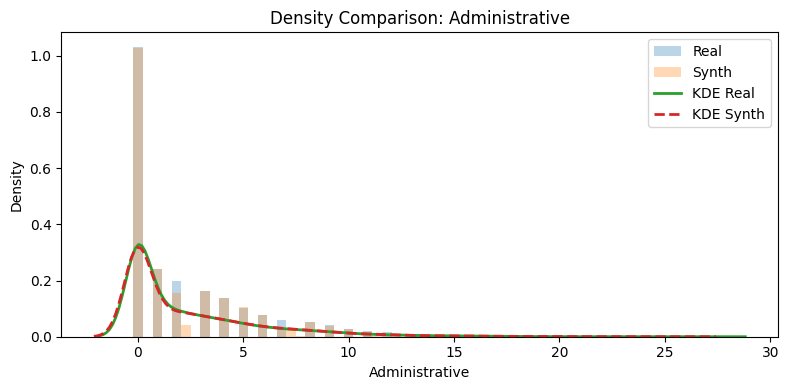

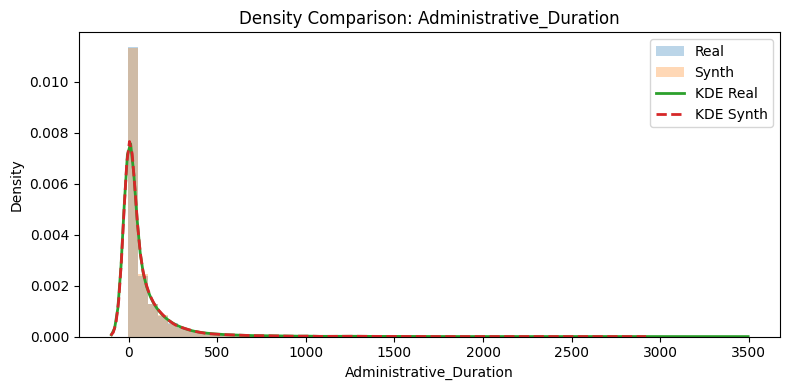

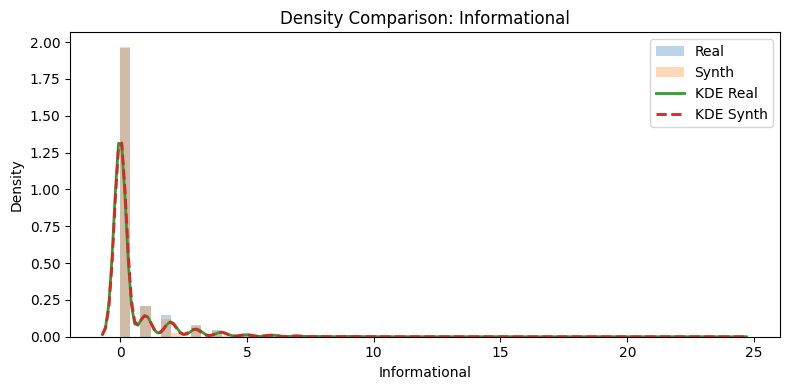

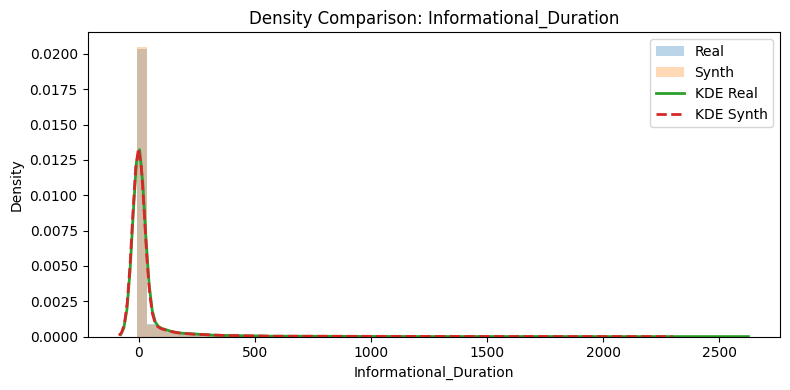

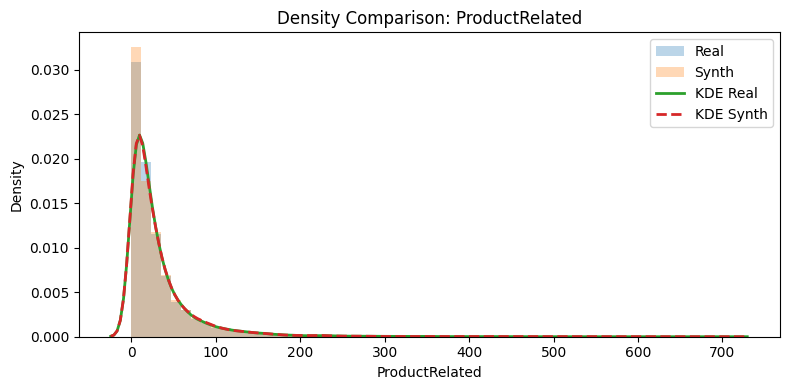

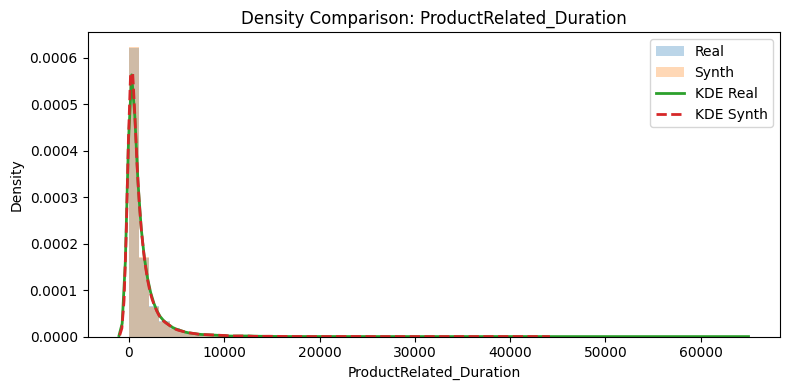

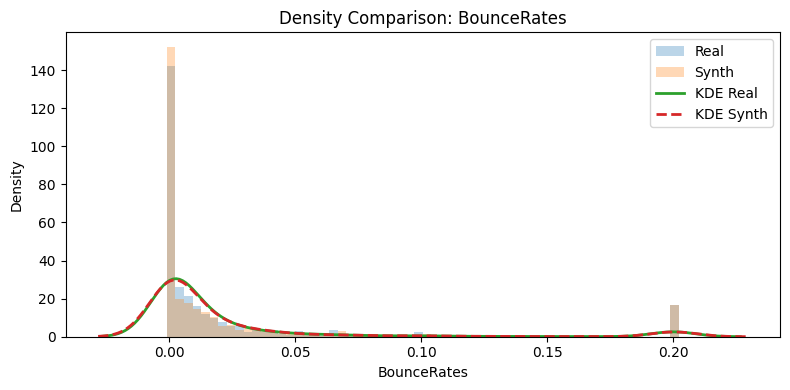

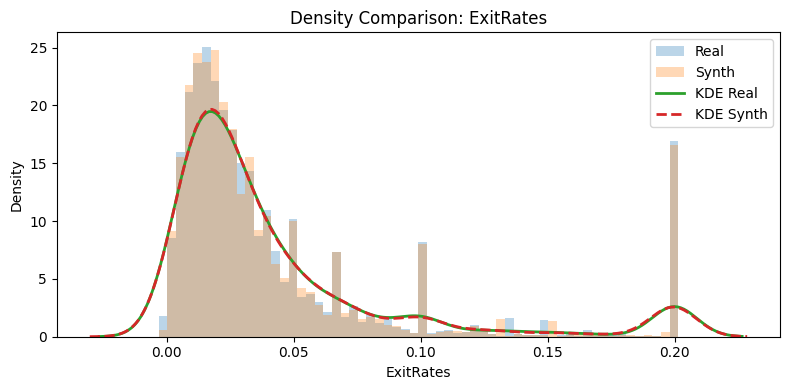

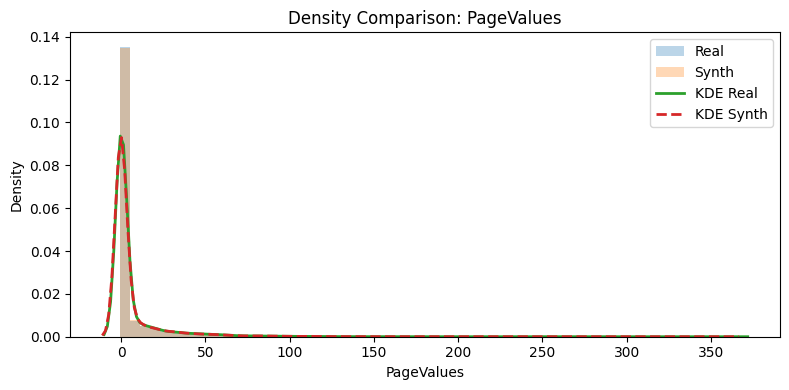

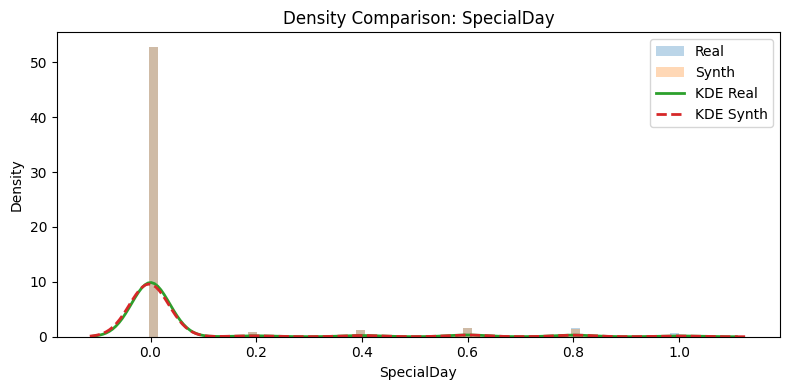

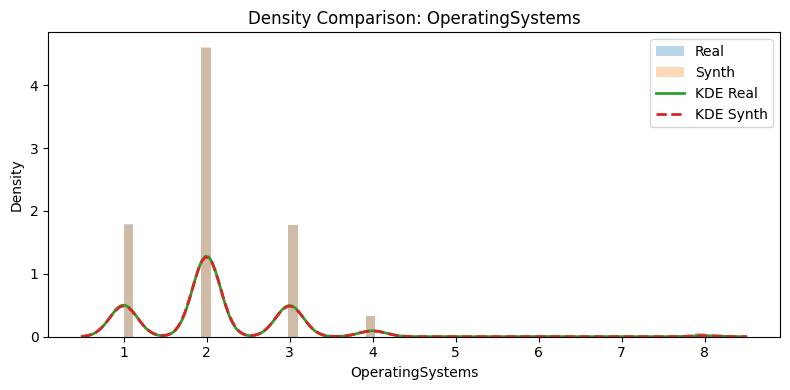

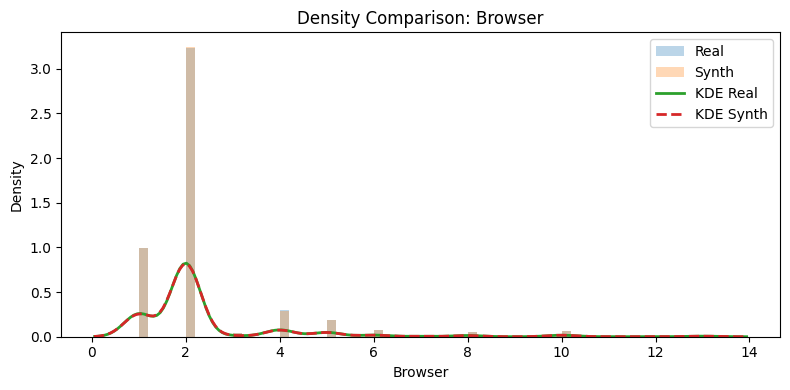

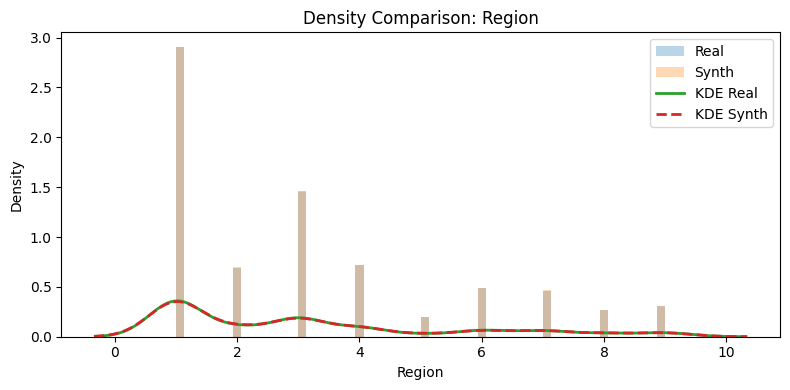

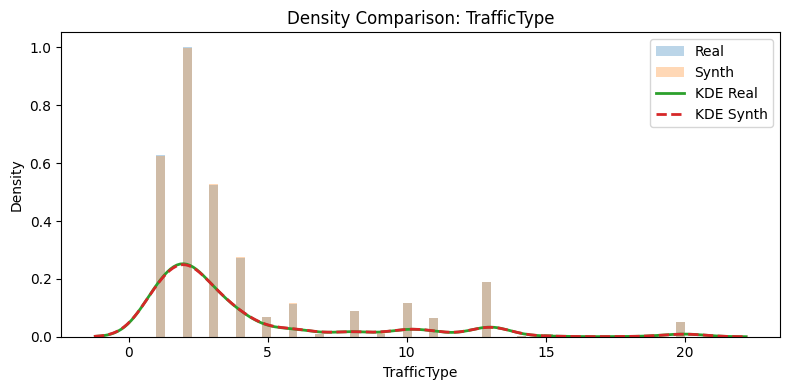

In [128]:
# Reconstrucción del dataset completo
assert list(df_real.columns) == list(df_reconstruct.columns)
# Ejecución para todas las numéricas
num_cols = df_real.select_dtypes(include='number').columns
for col in num_cols:
    plot_real_vs_synth_density_smooth(
        df_real, df_reconstruct,
        column=col,
        bins=60,
        bw_adjust=1.2,    # ajusta entre 0.5 (más detalle) y 2.0 (muy suave)
        figsize=(8, 4)
    )


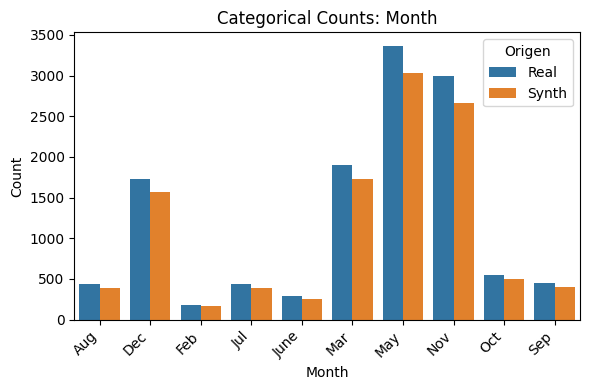

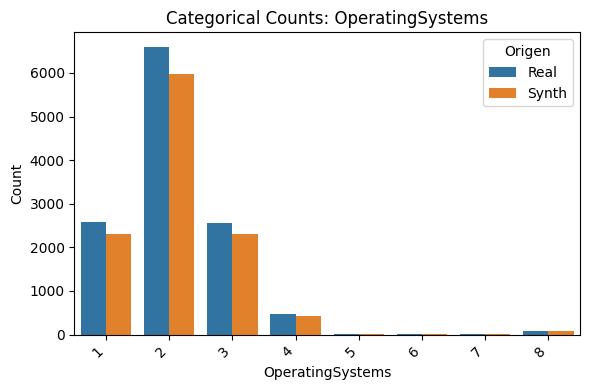

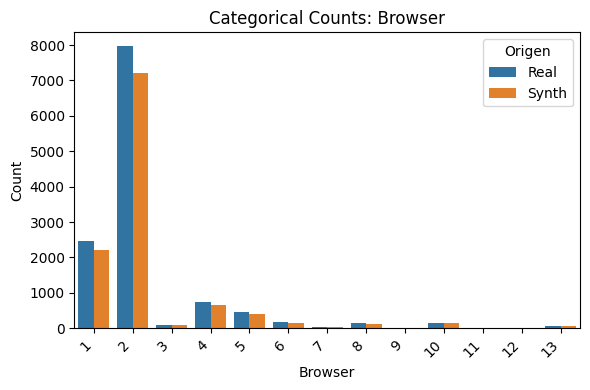

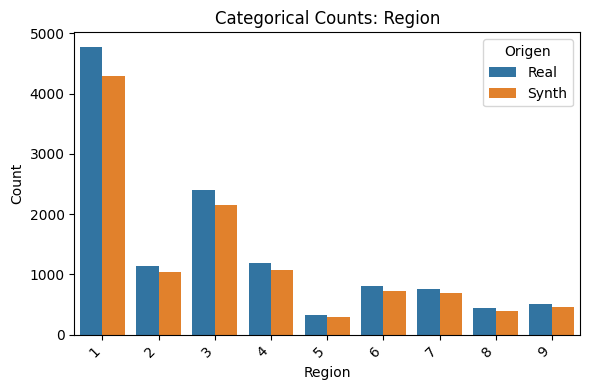

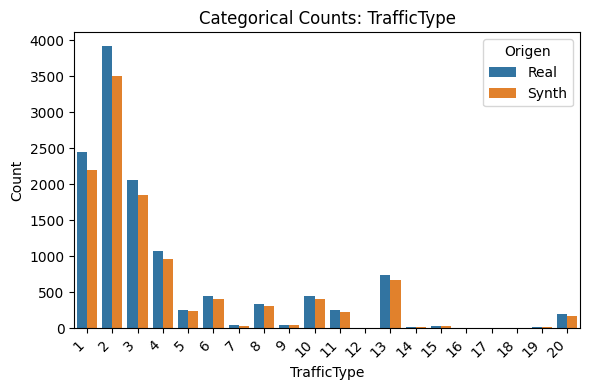

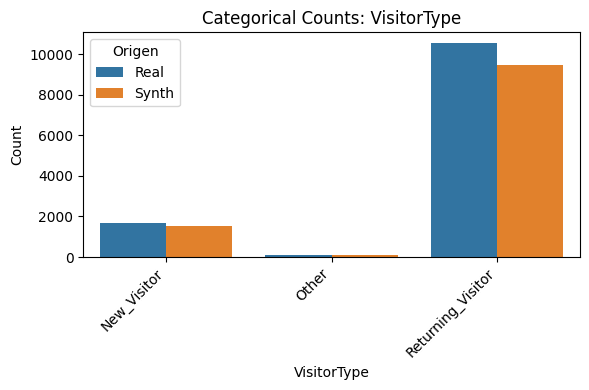

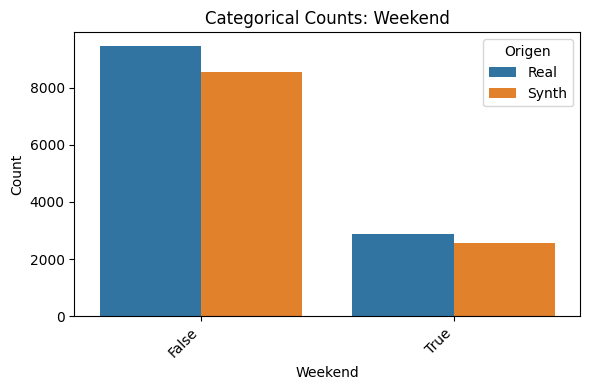

In [135]:
# --- Uso sobre todas las columnas categóricas ---
for col in cat_cols:
    plot_categorical_comparison(
        df_real, df_reconstruct,
        column=col,
        figsize=(6,4),
        palette={'Real':'C0','Synth':'C1'}
    )

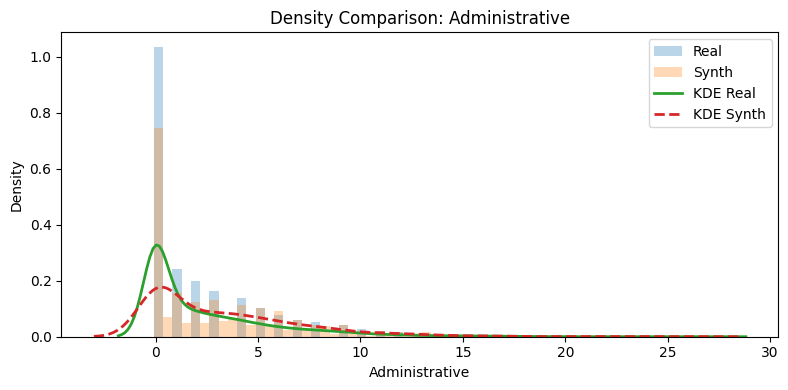

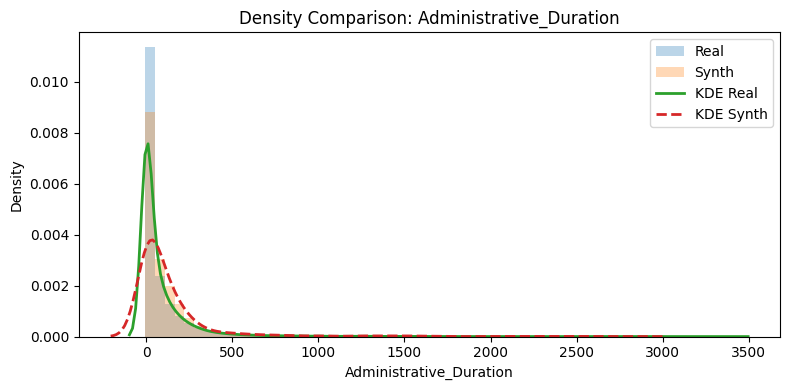

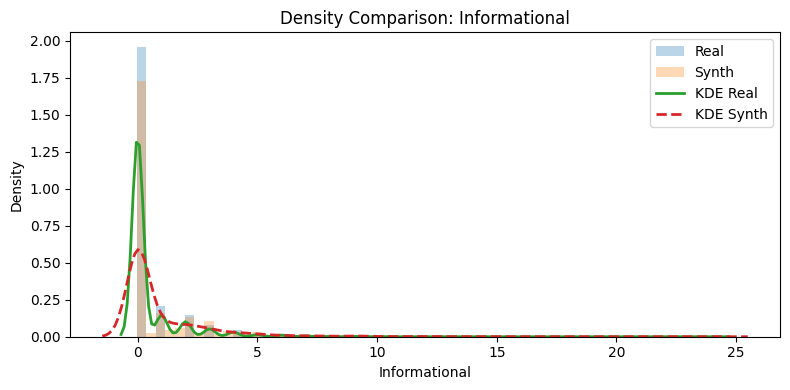

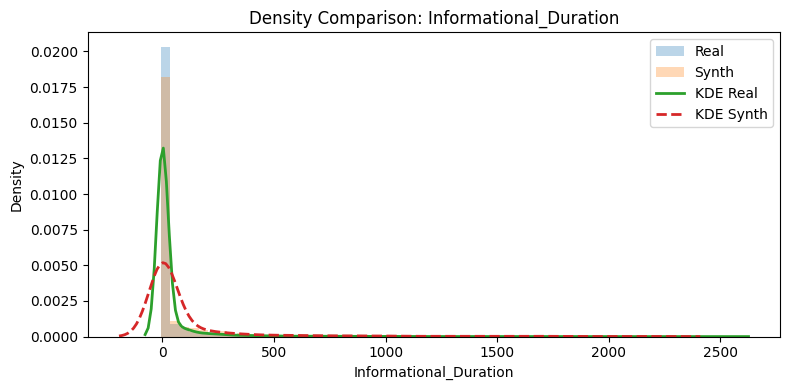

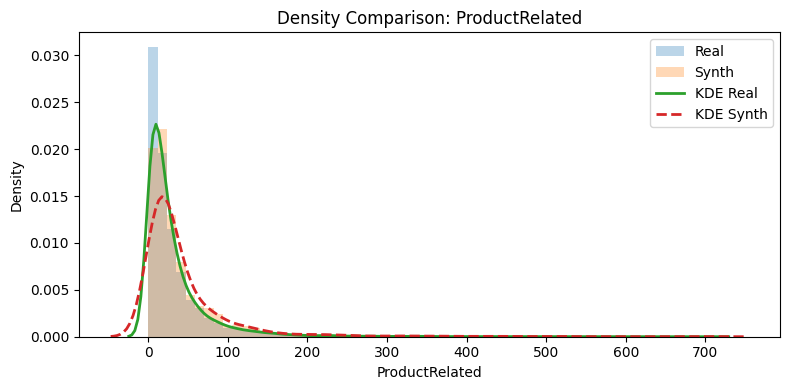

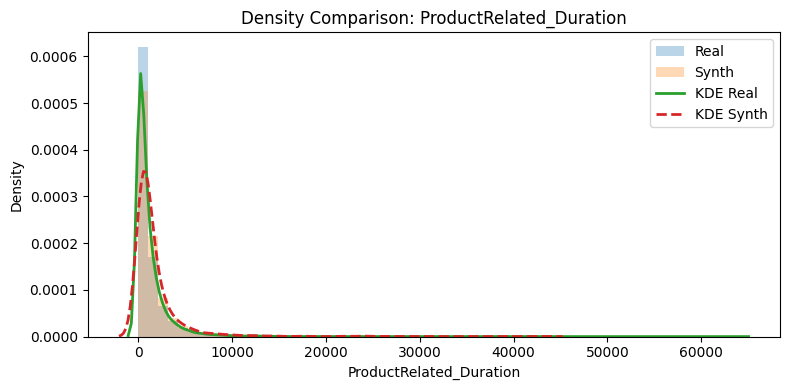

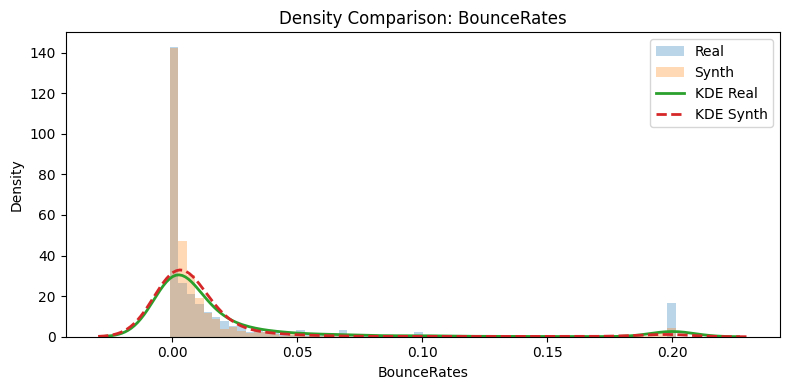

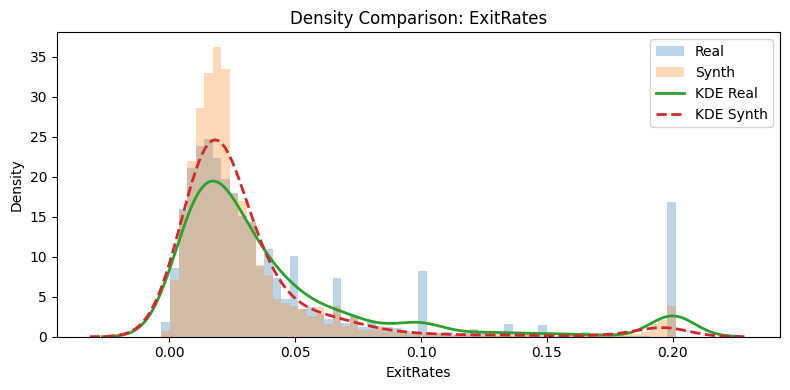

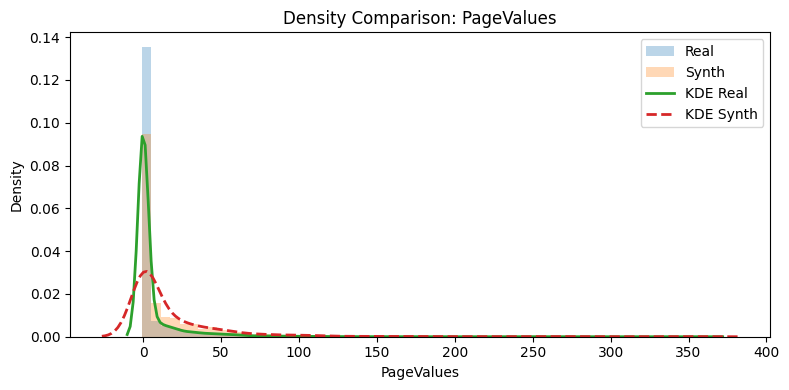

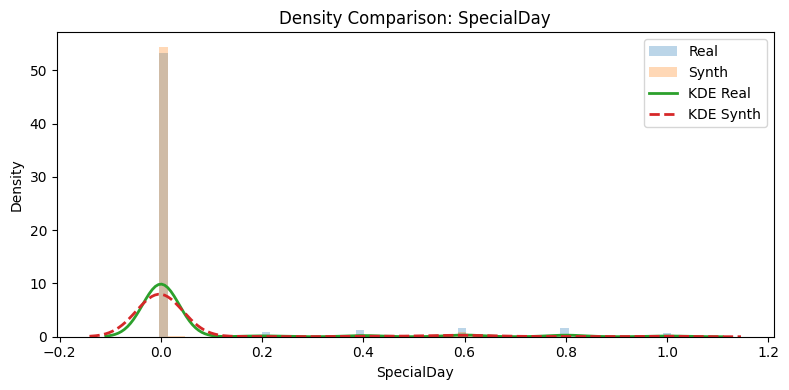

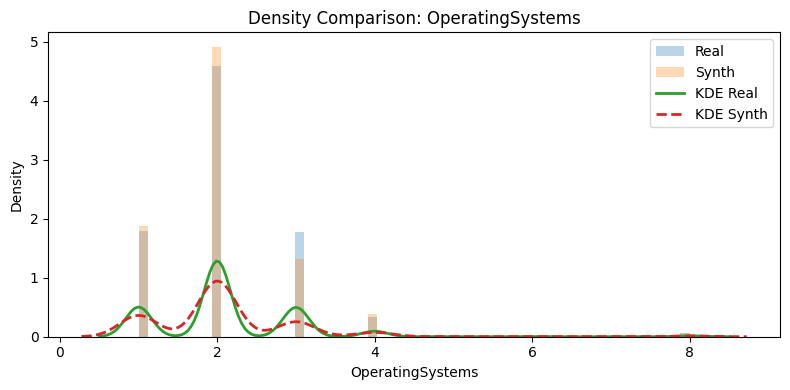

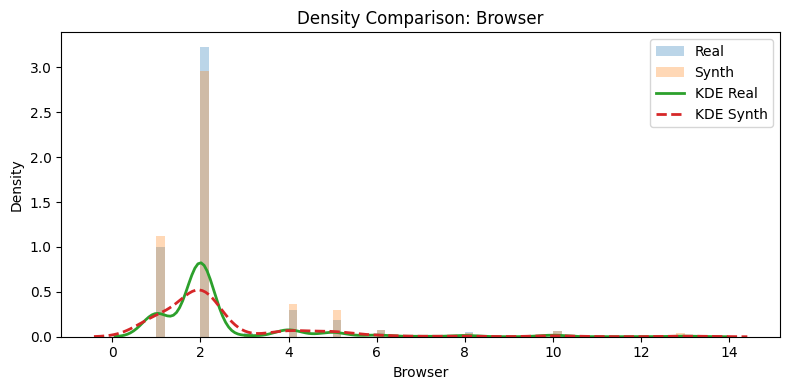

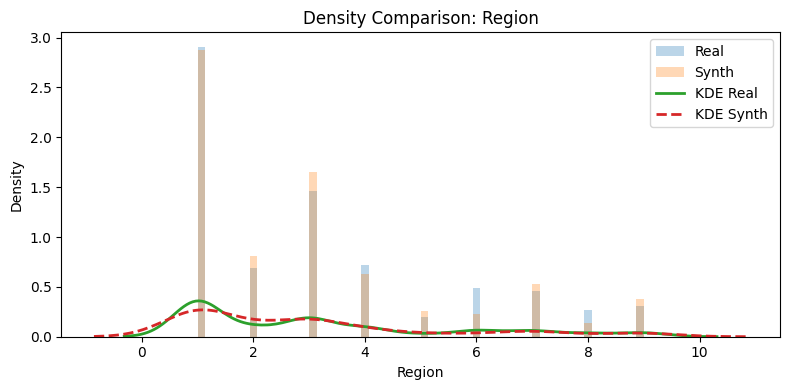

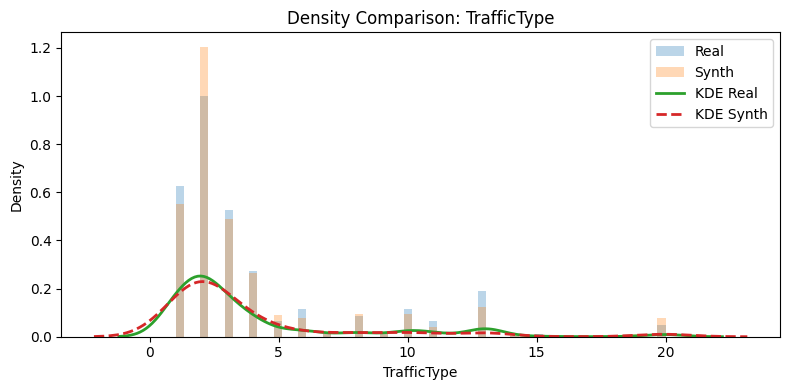

In [127]:
assert list(df_real.columns) == list(df_syn.columns)
# Ejecución para todas las numéricas
num_cols = df_real.select_dtypes(include='number').columns
for col in num_cols:
    plot_real_vs_synth_density_smooth(
        df_real, df_syn,
        column=col,
        bins=60,
        bw_adjust=1.2,    # ajusta entre 0.5 (más detalle) y 2.0 (muy suave)
        figsize=(8, 4)
    )


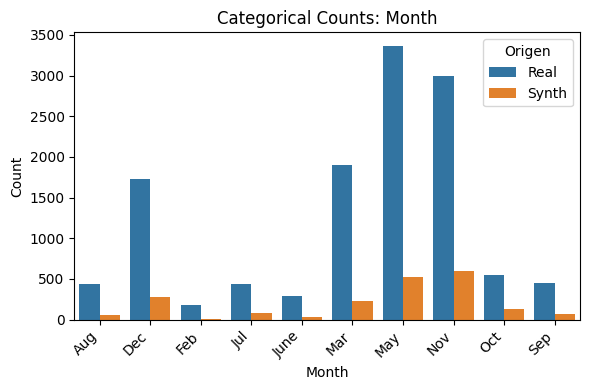

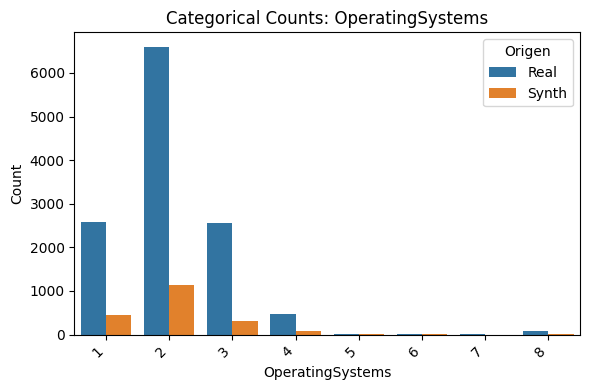

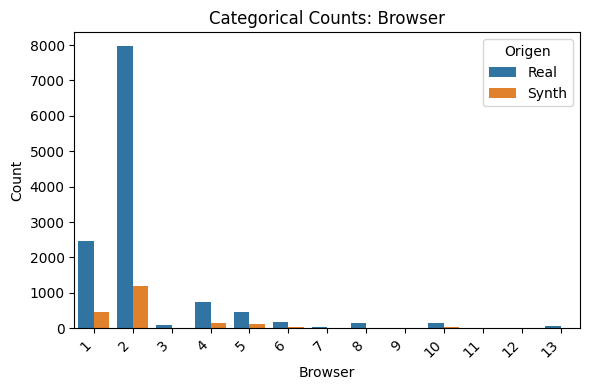

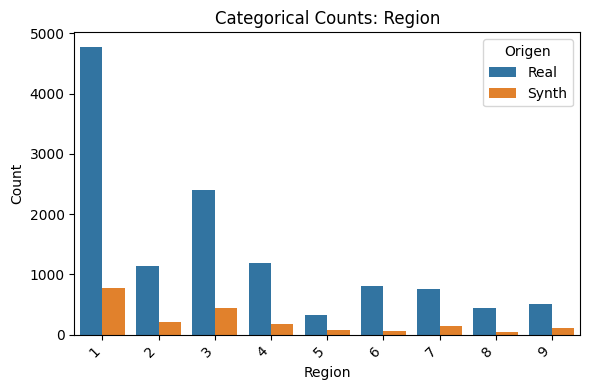

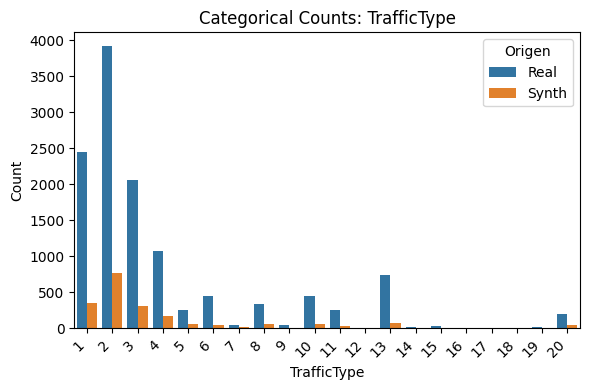

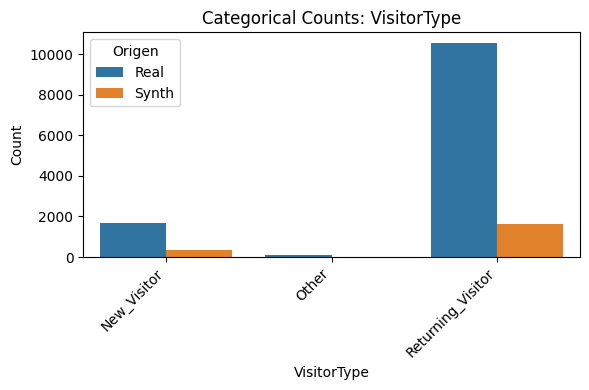

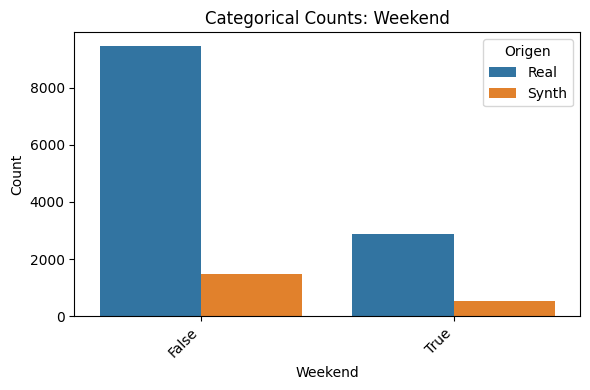

In [136]:
# --- Uso sobre todas las columnas categóricas ---
for col in cat_cols:
    plot_categorical_comparison(
        df_real, df_syn,
        column=col,
        figsize=(6,4),
        palette={'Real':'C0','Synth':'C1'}
    )

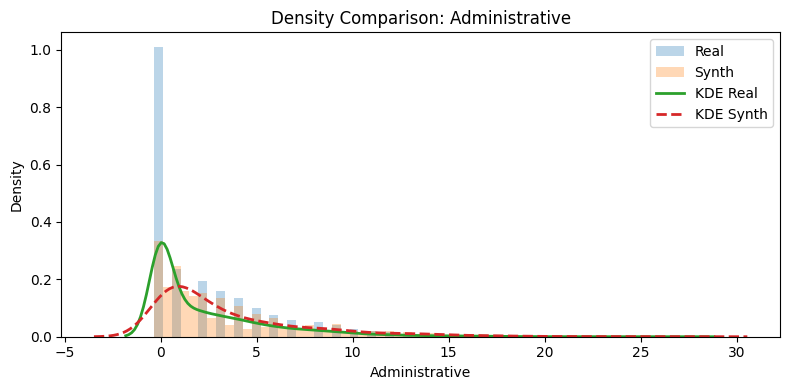

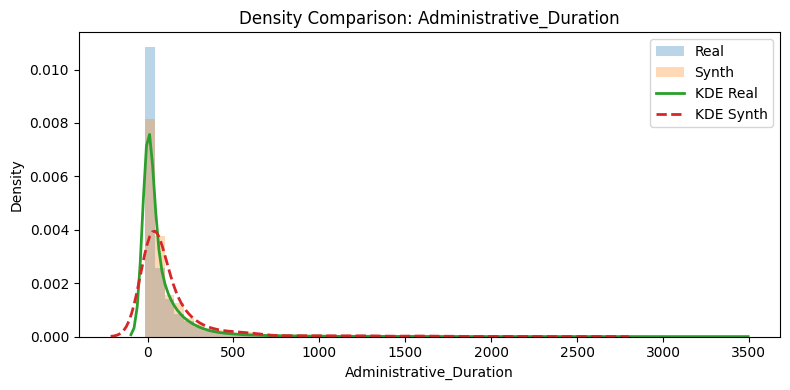

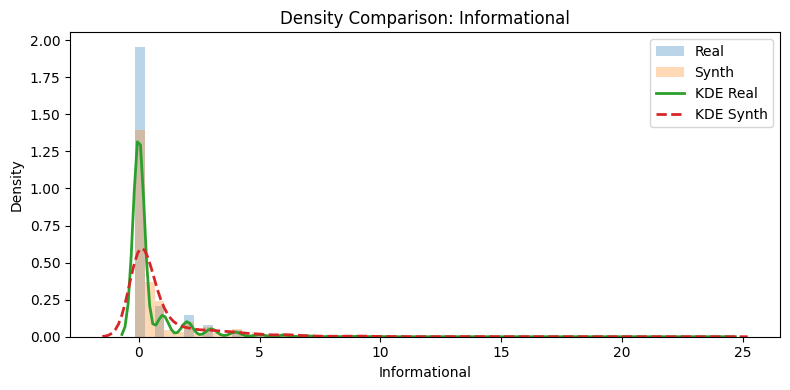

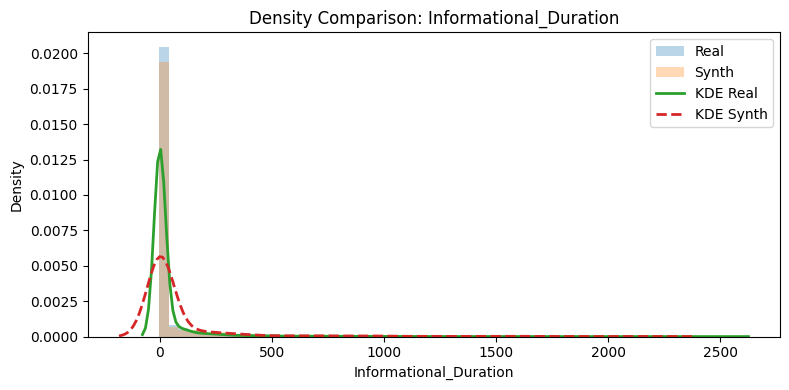

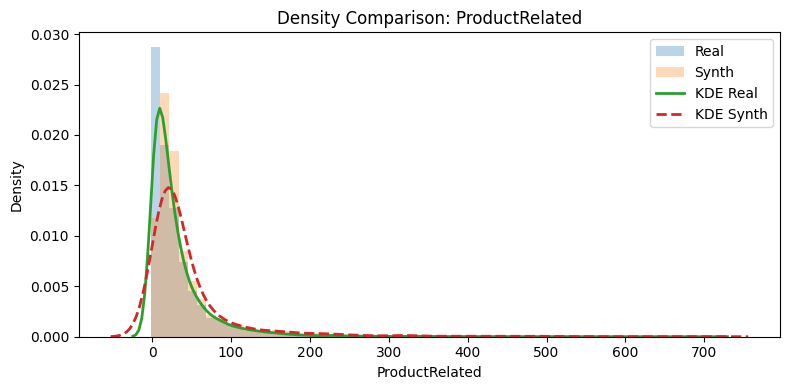

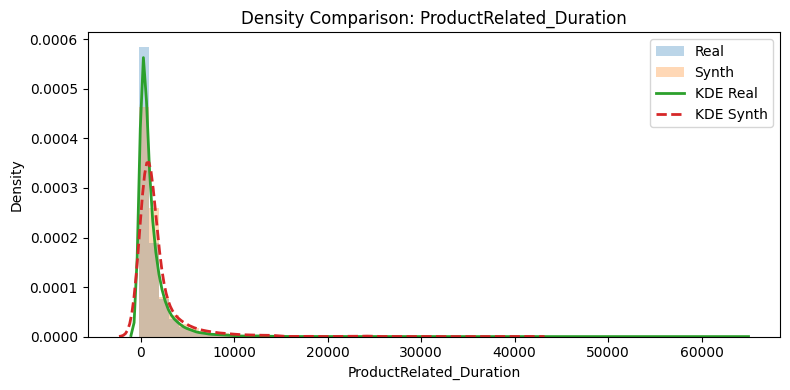

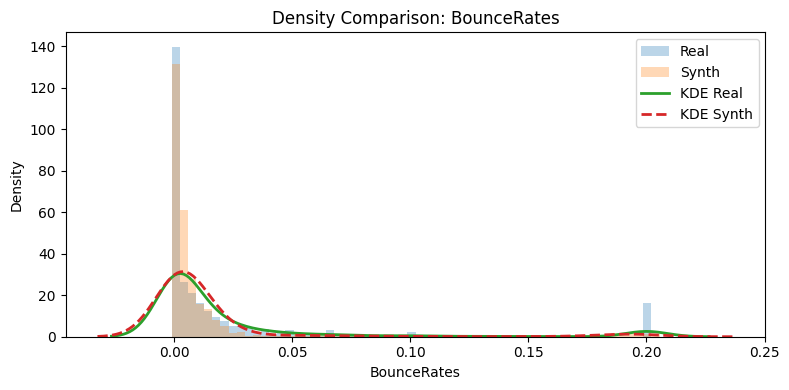

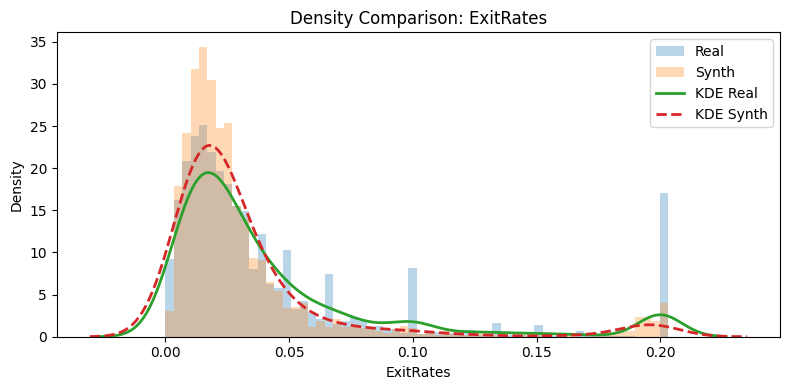

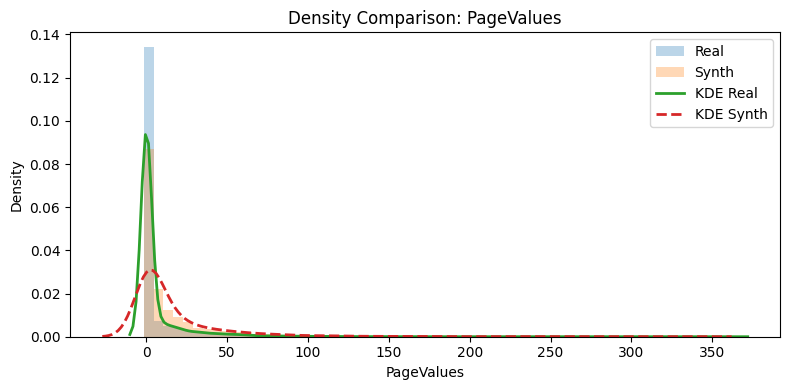

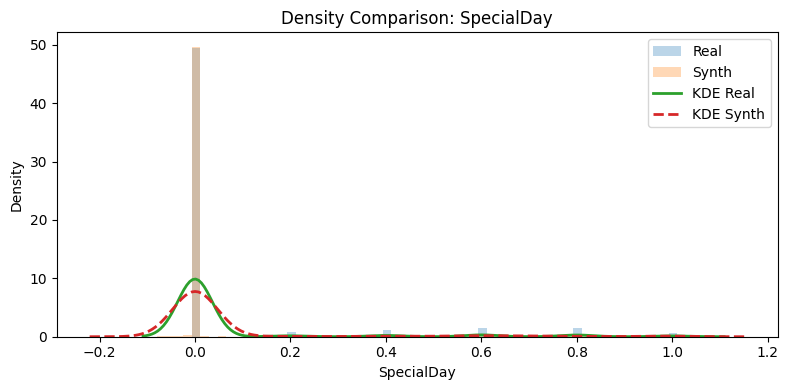

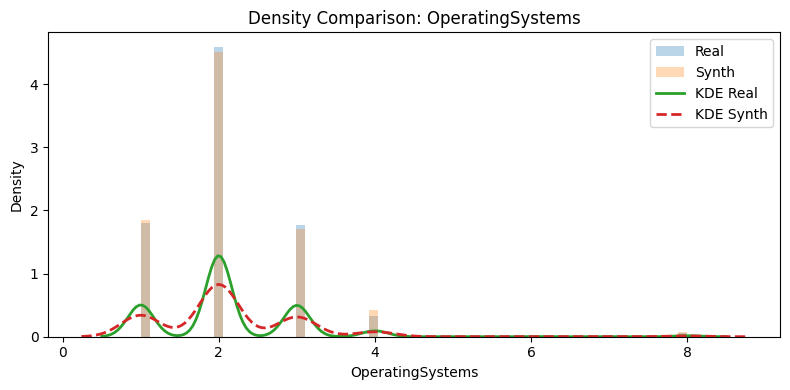

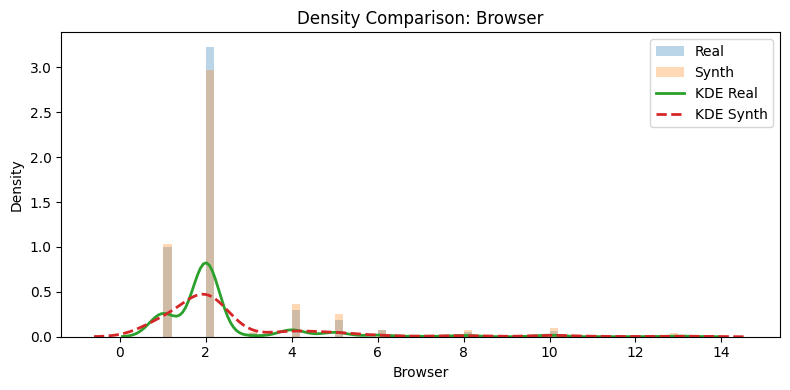

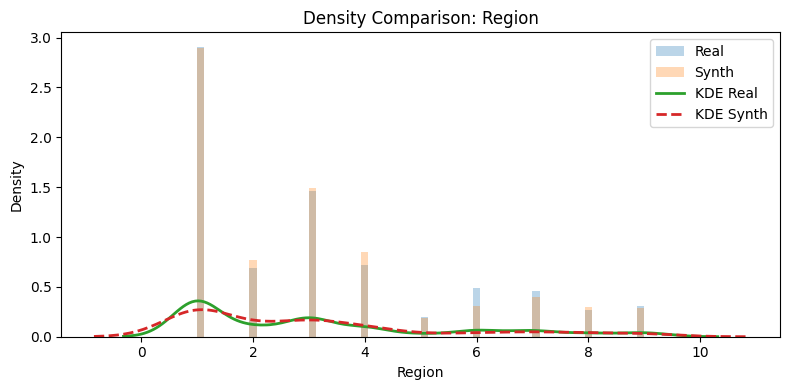

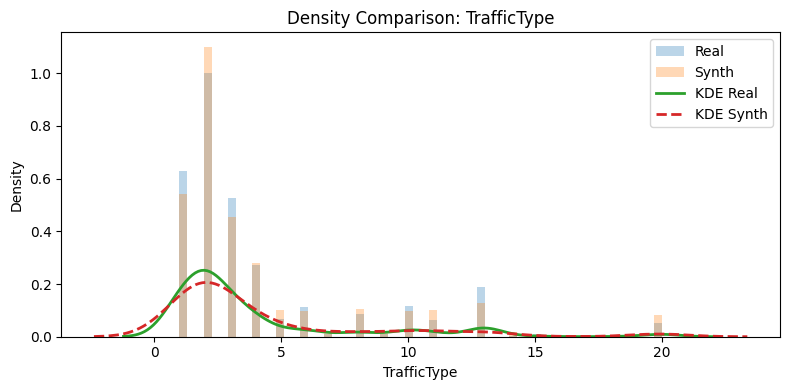

In [20]:
# Reconstrucción del dataset completo
assert list(df_real.columns) == list(df_syn_ft.columns)
# Ejecución para todas las numéricas
num_cols = df_real.select_dtypes(include='number').columns
for col in num_cols:
    plot_real_vs_synth_density_smooth(
        df_real, df_syn_ft,
        column=col,
        bins=60,
        bw_adjust=1.2,    # ajusta entre 0.5 (más detalle) y 2.0 (muy suave)
        figsize=(8, 4)
    )

0.11018713958805994


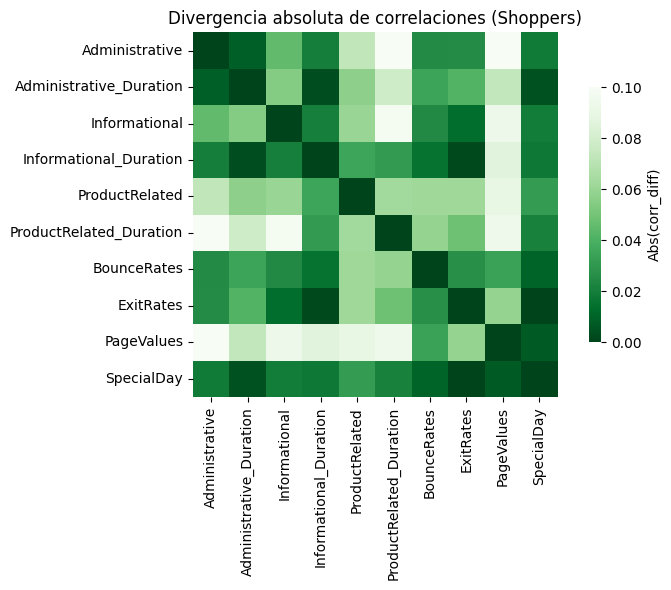

In [149]:
plot_shoppers_corr_divergence(df_real.loc[:,num_cols], df_syn.loc[:,num_cols])

0.0


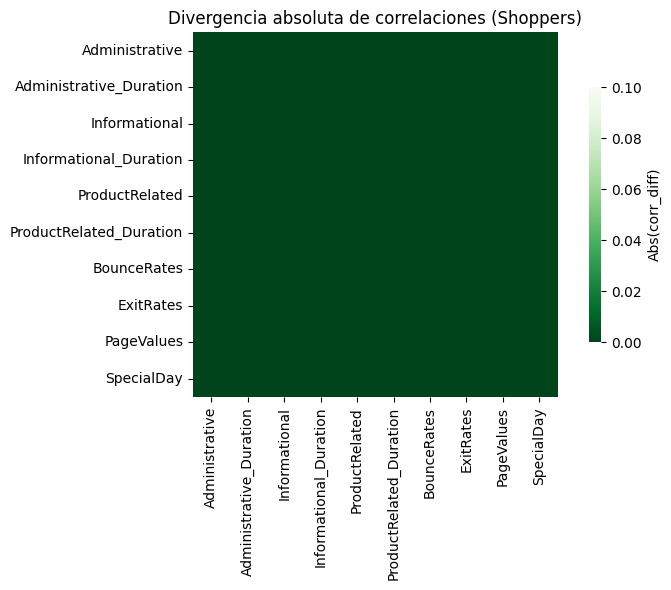

In [150]:
plot_shoppers_corr_divergence(df_real.loc[:,num_cols], df_real.loc[:,num_cols])

0.034824172008416476


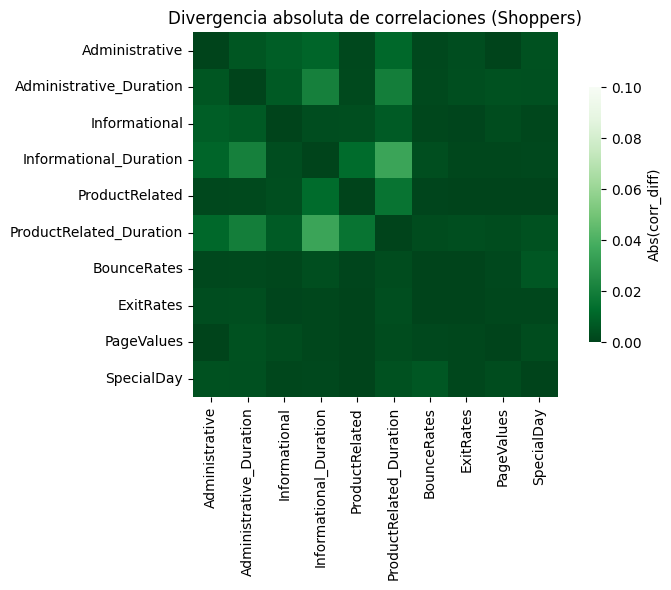

In [151]:
plot_shoppers_corr_divergence(df_real.loc[:,num_cols], df_reconstruct.loc[:,num_cols])